# Unsupervised Learning: Trade&Ahead

**Marks: 60**

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')


pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 200)


from sklearn.preprocessing import StandardScaler


from scipy.spatial.distance import cdist, pdist


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer


from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet


import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/My Drive/stock_data.csv')

## Data Overview

- Observations
- Sanity checks

### Checking the shape of the dataset

In [ ]:

print(f"There are {'______'} rows and {'______'} columns.") ## Complete the code to get the shape of data

There are ______ rows and ______ columns.


### Displaying few rows of the dataset

In [ ]:
# let's view a sample of the data
data.sample(n=10, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620


### Checking the data types of the columns for the dataset

In [ ]:
# checking the column names and datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

### Creating a copy of original data

In [ ]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

### Checking for duplicates and missing values

In [ ]:
# checking for duplicate values
print(f"Total number of duplicate values: {df.duplicated().sum()}") # Complete the code to get total number of duplicate values


Total number of duplicate values: 0


In [ ]:
# checking for missing values in the data
print(df.isna().sum()) ## Complete the code to check the missing values in the data


Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64


### Statistical summary of the dataset

**Let's check the statistical summary of the data.**

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticker Symbol,340,340,AAL,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Security,340,340,American Airlines Group,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS Sector,340,11,Industrials,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS Sub Industry,340,104,Oil & Gas Exploration & Production,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Price,340.0,NaN,NaN,NaN,80.862345,98.055086,4.5,38.555,59.705,92.880001,1274.949951
Price Change,340.0,NaN,NaN,NaN,4.078194,12.006338,-47.129693,-0.939484,4.819505,10.695493,55.051683
Volatility,340.0,NaN,NaN,NaN,1.525976,0.591798,0.733163,1.134878,1.385593,1.695549,4.580042
ROE,340.0,NaN,NaN,NaN,39.597059,96.547538,1.0,9.75,15.0,27.0,917.0
Cash Ratio,340.0,NaN,NaN,NaN,70.023529,90.421331,0.0,18.0,47.0,99.0,958.0
Net Cash Flow,340.0,NaN,NaN,NaN,55537620.588235,1946365312.175789,-11208000000.0,-193906500.0,2098000.0,169810750.0,20764000000.0


Data Overview
Shape of the Dataset: There are 340 rows and 15 columns. This means you have data on 340 different stocks with 15 attributes each.
Sample Data
A random sample of 10 stocks from the dataset includes various companies across different GICS Sectors, such as Energy, Information Technology, Real Estate, Consumer Staples, Consumer Discretionary, and Financials. This diversity suggests a good representation across different market segments, which is beneficial for clustering and analysis.

Data Types
The dataset contains a mix of numerical (float64 and int64) and categorical (object) data types, suitable for the intended analyses like clustering (which primarily uses numerical data) and group-wise comparisons among GICS Sectors or Sub Industries.

Duplicates and Missing Values
Duplicates: There are no duplicate rows in the dataset, indicating each stock entry is unique.
Missing Values: There are no missing values across all columns, which means the dataset is complete and does not require imputation for missing data.
Statistical Summary
The describe method's summary includes counts, means, standard deviations, and the distribution (min, 25%, 50%, 75%, max) for numerical columns. It indicates a wide range of values across different financial metrics like Current Price, Price Change, Volatility, etc. For example, P/E Ratio ranges from 2.93 to 528.04, suggesting a significant variation in valuation among the stocks.
The count for categorical columns (like GICS Sector and Sub Industry) is 340 for each, confirming there are no missing entries.

## Exploratory Data Analysis

### Univariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

**`Current Price`**

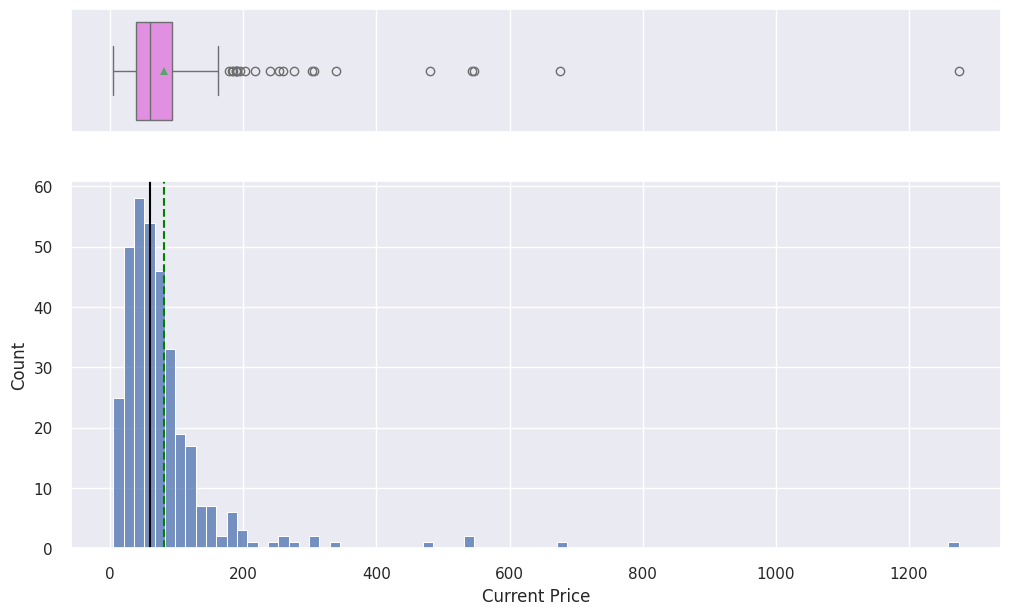

In [ ]:
histogram_boxplot(df, 'Current Price')

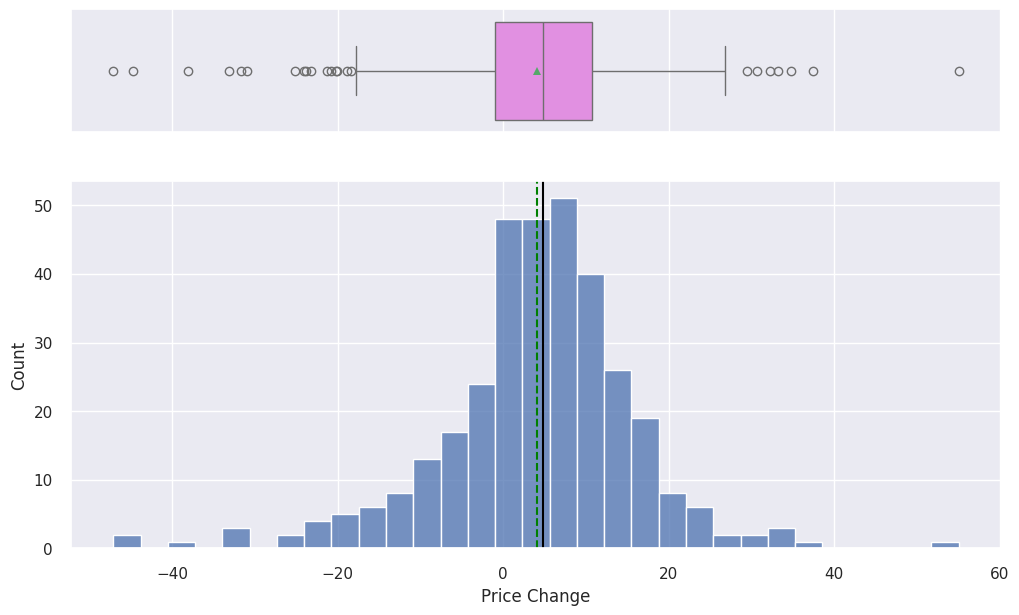

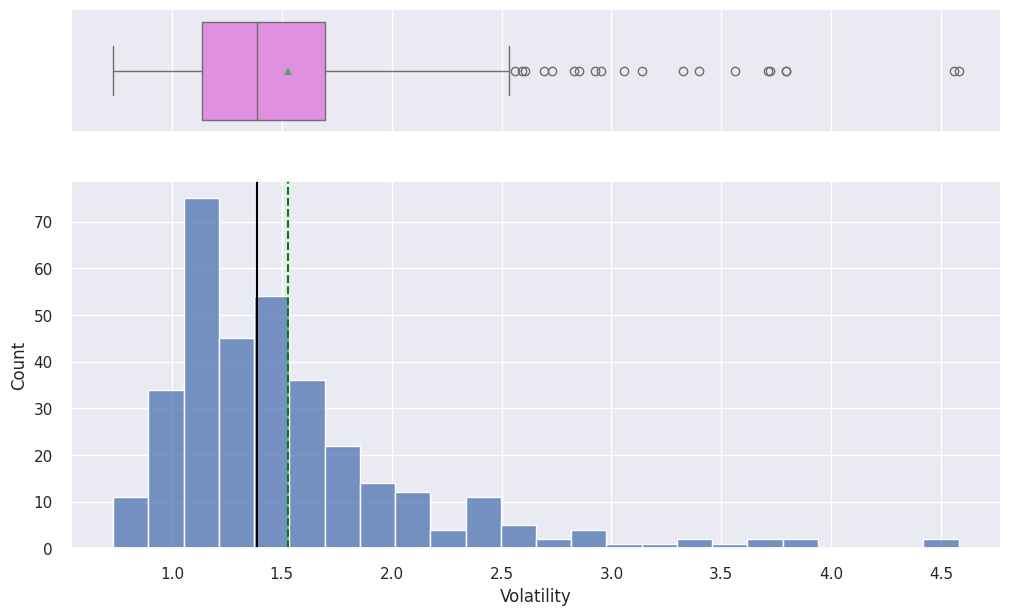

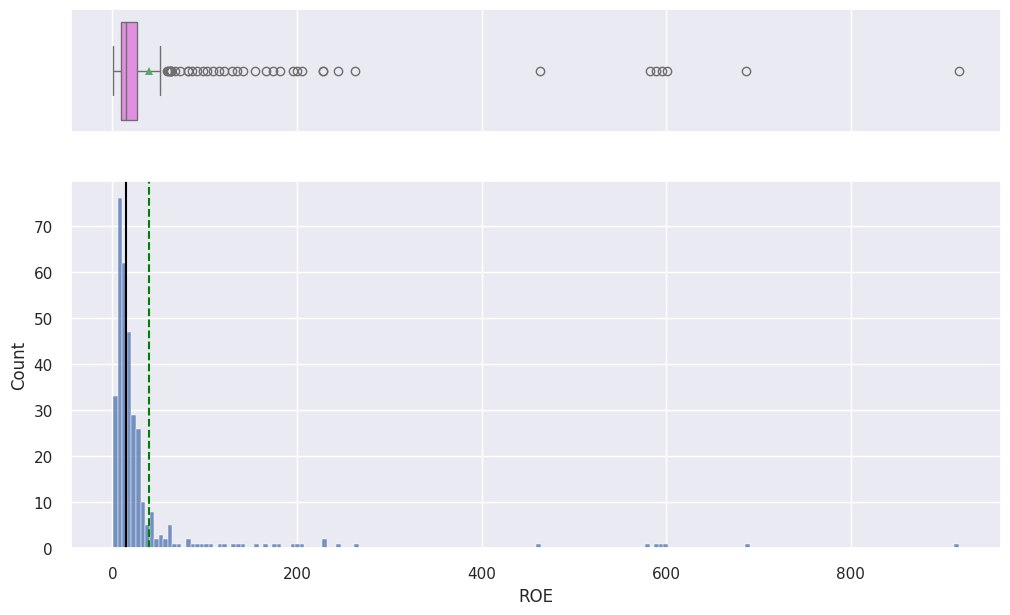

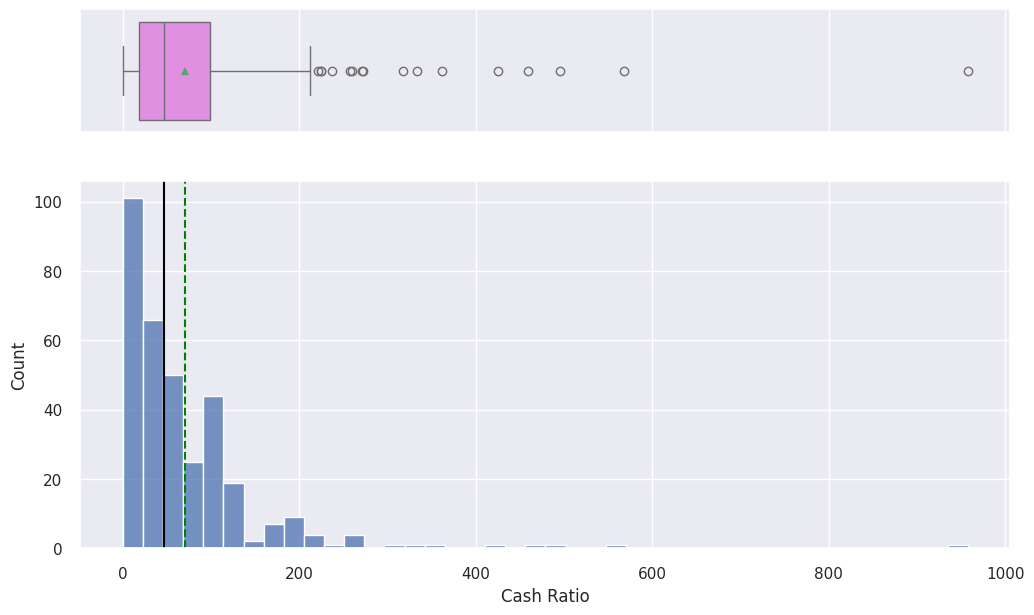

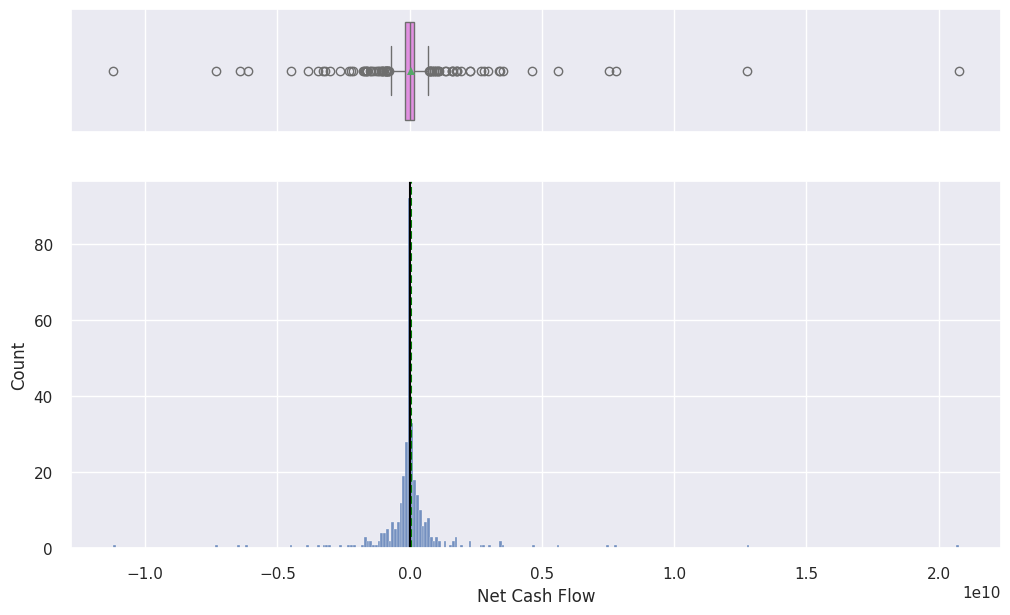

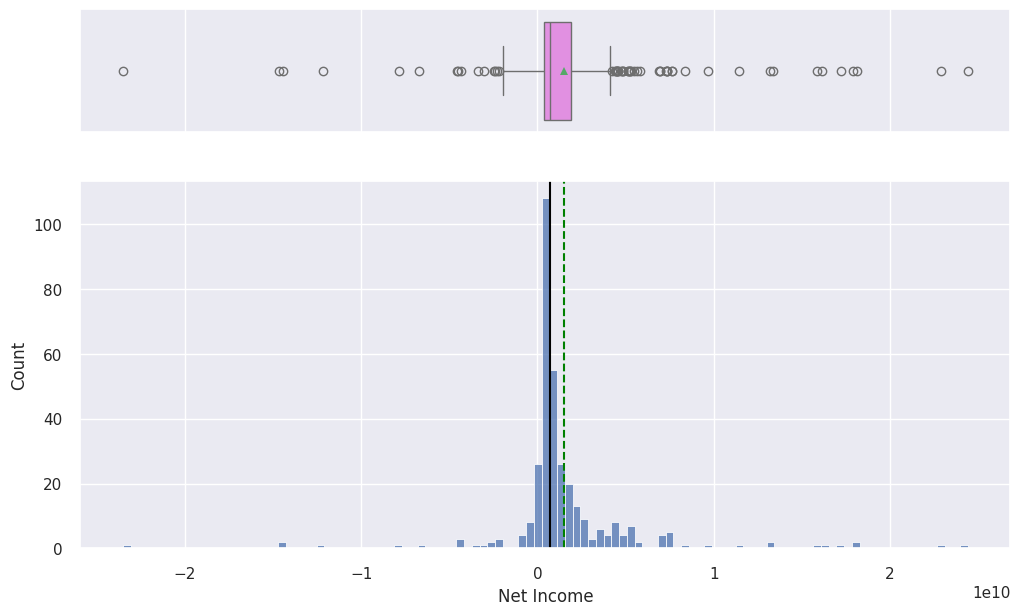

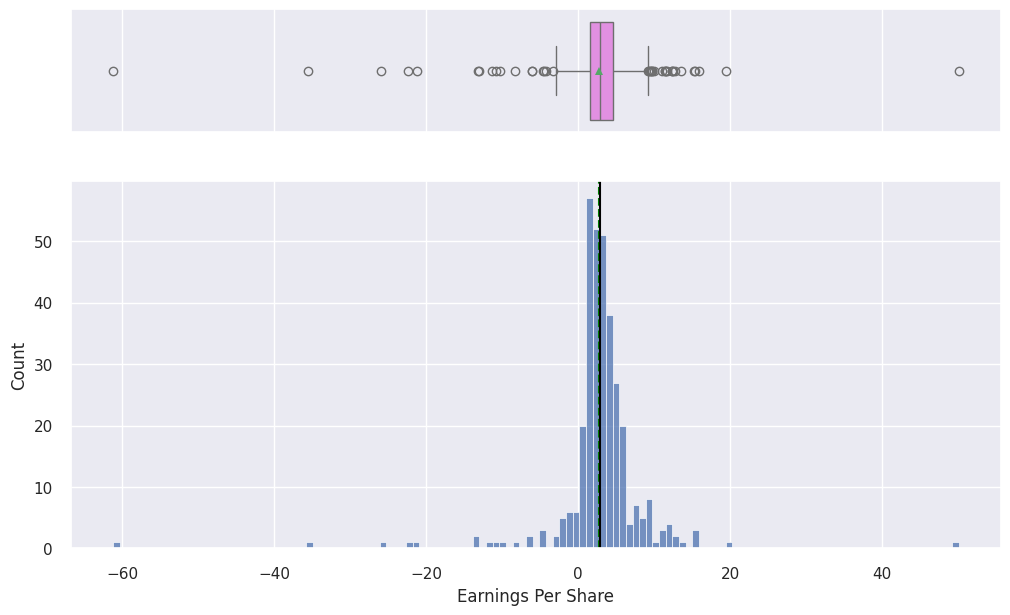

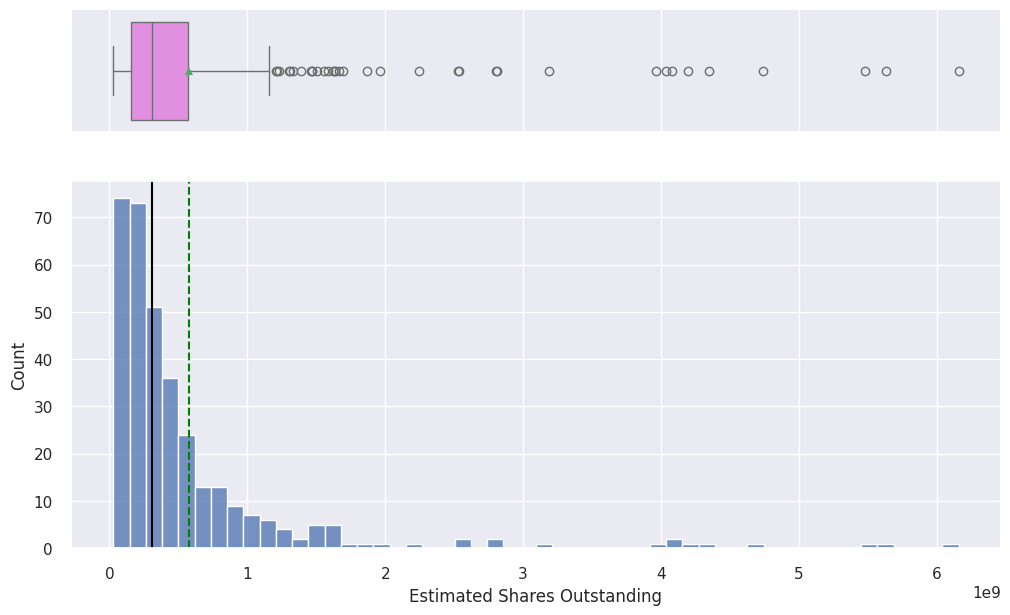

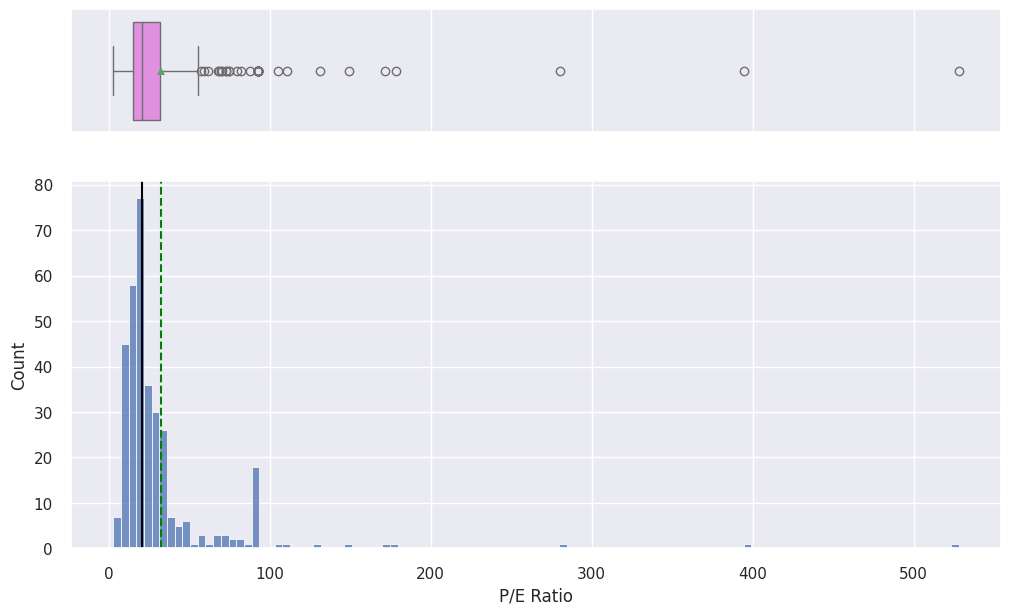

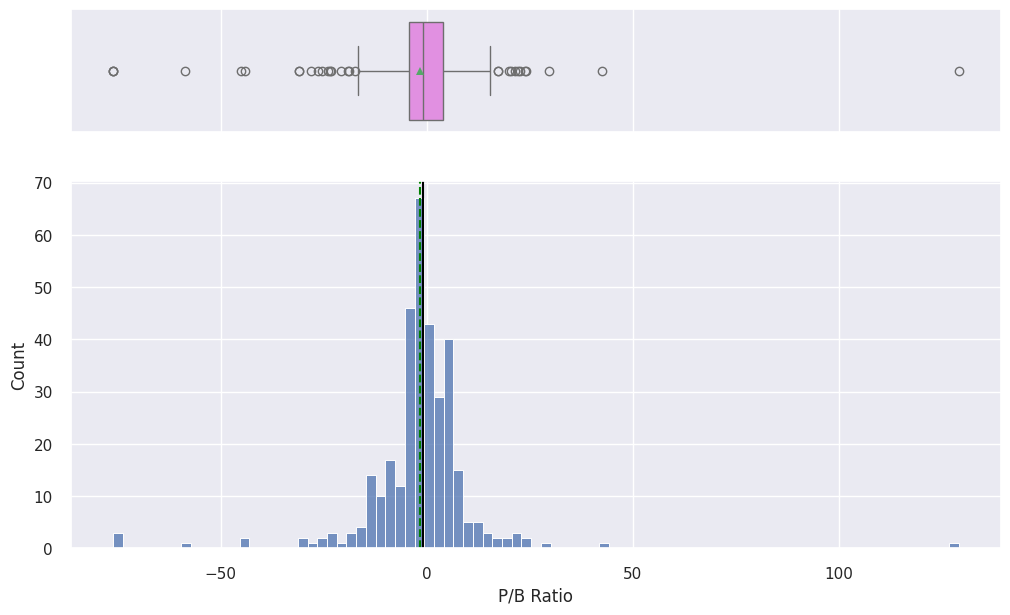

In [ ]:
histogram_boxplot(df, 'Price Change')  ## Complete the code to create histogram_boxplot for 'Price Change'

histogram_boxplot(df, 'Volatility')  ## Complete the code to create histogram_boxplot for 'Volatility'

histogram_boxplot(df, 'ROE')  ## Complete the code to create histogram_boxplot for 'ROE'

histogram_boxplot(df, 'Cash Ratio')  ## Complete the code to create histogram_boxplot for 'Cash Ratio'

histogram_boxplot(df, 'Net Cash Flow')  ## Complete the code to create histogram_boxplot for 'Net Cash Flow'

histogram_boxplot(df, 'Net Income')  ## Complete the code to create histogram_boxplot for 'Net Income'

histogram_boxplot(df, 'Earnings Per Share')  ## Complete the code to create histogram_boxplot for 'Earnings Per Share'

histogram_boxplot(df, 'Estimated Shares Outstanding')  ## Complete the code to create histogram_boxplot for 'Estimated Shares Outstanding'

histogram_boxplot(df, 'P/E Ratio')  ## Complete the code to create histogram_boxplot for 'P/E Ratio'

histogram_boxplot(df, 'P/B Ratio')  ## Complete the code to create histogram_boxplot for 'P/B Ratio'


In [ ]:
# function to create labeled barplots


def labeled_barplot(df, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(df[feature])  # length of the column
    count = df[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=df,
        x=feature,
        palette="Paired",
        order=df[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**`GICS Sector`**

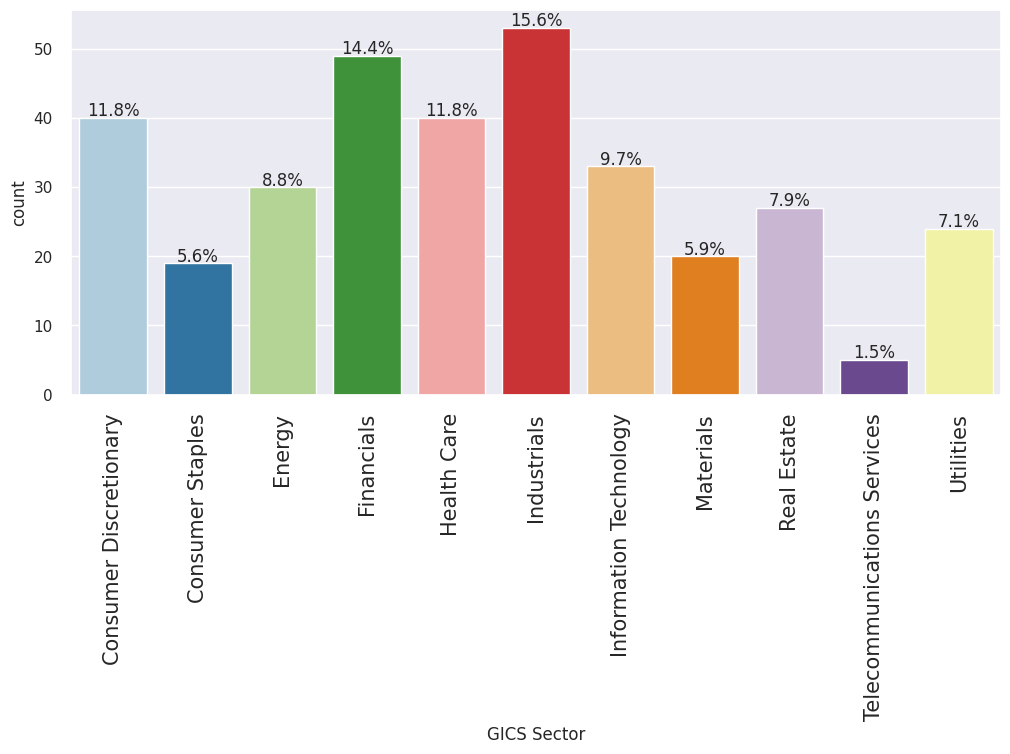

In [ ]:
labeled_barplot(df, 'GICS Sector', perc=True)

**`GICS Sub Industry`**

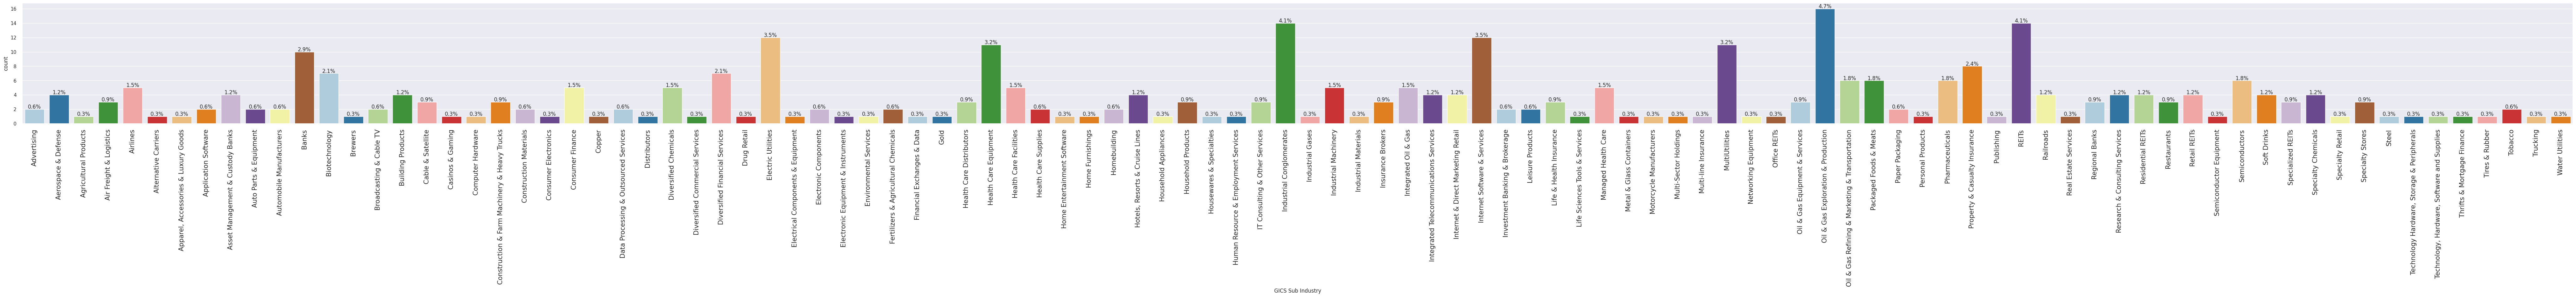

In [ ]:
labeled_barplot(df, 'GICS Sub Industry', perc=True)


### Bivariate Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
print(df.head())  # Check the first few rows of the DataFrame


  Ticker Symbol                 Security             GICS Sector  \
0           AAL  American Airlines Group             Industrials   
1          ABBV                   AbbVie             Health Care   
2           ABT      Abbott Laboratories             Health Care   
3          ADBE        Adobe Systems Inc  Information Technology   
4           ADI     Analog Devices, Inc.  Information Technology   

       GICS Sub Industry  Current Price  Price Change  Volatility  ROE  \
0               Airlines      42.349998      9.999995    1.687151  135   
1        Pharmaceuticals      59.240002      8.339433    2.197887  130   
2  Health Care Equipment      44.910000     11.301121    1.273646   21   
3   Application Software      93.940002     13.977195    1.357679    9   
4         Semiconductors      55.320000     -1.827858    1.701169   14   

   Cash Ratio  Net Cash Flow  Net Income  Earnings Per Share  \
0          51     -604000000  7610000000               11.39   
1          77     

In [ ]:
df.select_dtypes(include=['float64', 'int64']).info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Current Price                 340 non-null    float64
 1   Price Change                  340 non-null    float64
 2   Volatility                    340 non-null    float64
 3   ROE                           340 non-null    int64  
 4   Cash Ratio                    340 non-null    int64  
 5   Net Cash Flow                 340 non-null    int64  
 6   Net Income                    340 non-null    int64  
 7   Earnings Per Share            340 non-null    float64
 8   Estimated Shares Outstanding  340 non-null    float64
 9   P/E Ratio                     340 non-null    float64
 10  P/B Ratio                     340 non-null    float64
dtypes: float64(7), int64(4)
memory usage: 29.3 KB


In [ ]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])


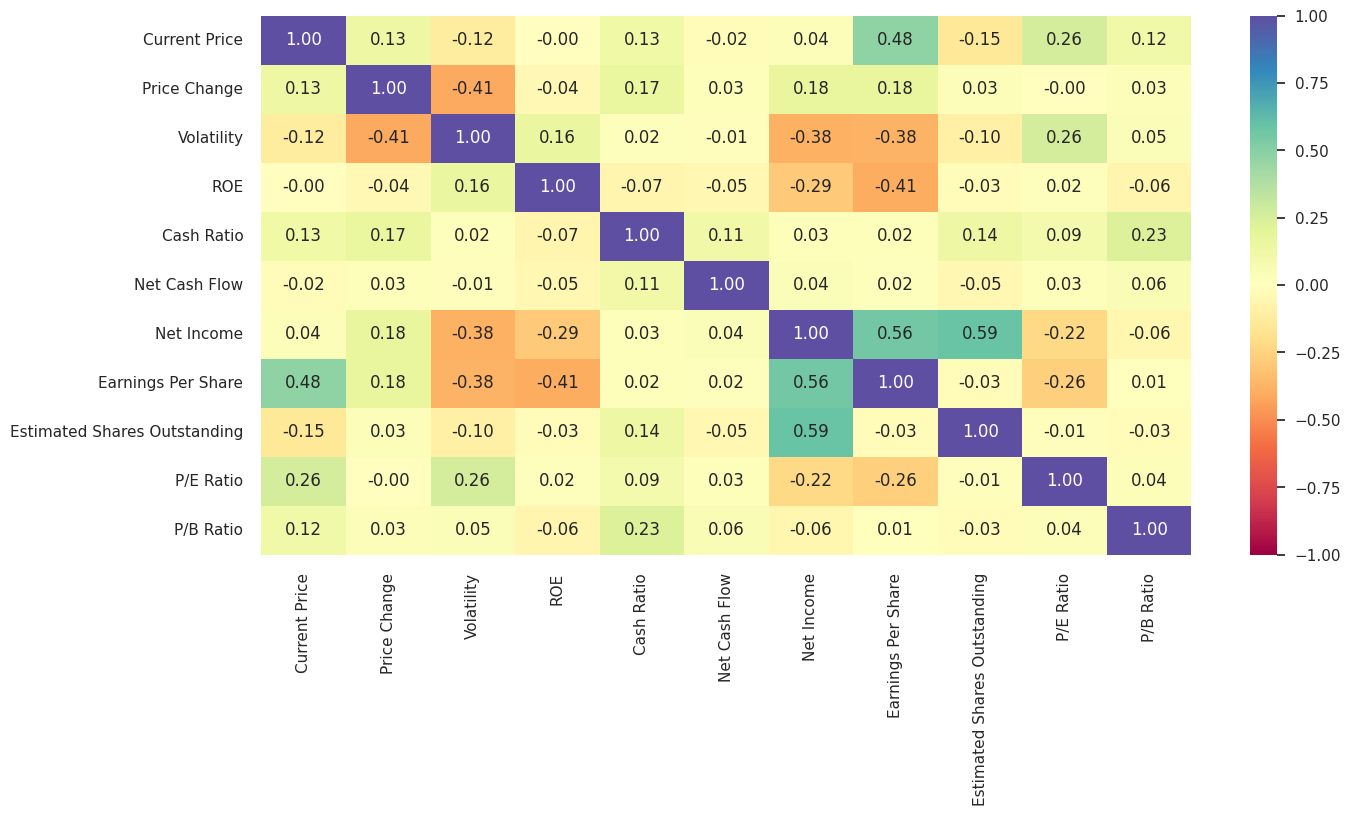

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(
    df_numeric.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()


In [ ]:
print(df_numeric.head())


   Current Price  Price Change  Volatility  ROE  Cash Ratio  Net Cash Flow  \
0      42.349998      9.999995    1.687151  135          51     -604000000   
1      59.240002      8.339433    2.197887  130          77       51000000   
2      44.910000     11.301121    1.273646   21          67      938000000   
3      93.940002     13.977195    1.357679    9         180     -240840000   
4      55.320000     -1.827858    1.701169   14         272      315120000   

   Net Income  Earnings Per Share  Estimated Shares Outstanding   P/E Ratio  \
0  7610000000               11.39                  6.681299e+08    3.718174   
1  5144000000                3.15                  1.633016e+09   18.806350   
2  4423000000                2.94                  1.504422e+09   15.275510   
3   629551000                1.26                  4.996437e+08   74.555557   
4   696878000                0.31                  2.247994e+09  178.451613   

   P/B Ratio  
0  -8.784219  
1  -8.750068  
2  -0.39417

**Let's check the stocks of which economic sector have seen the maximum price increase on average.**

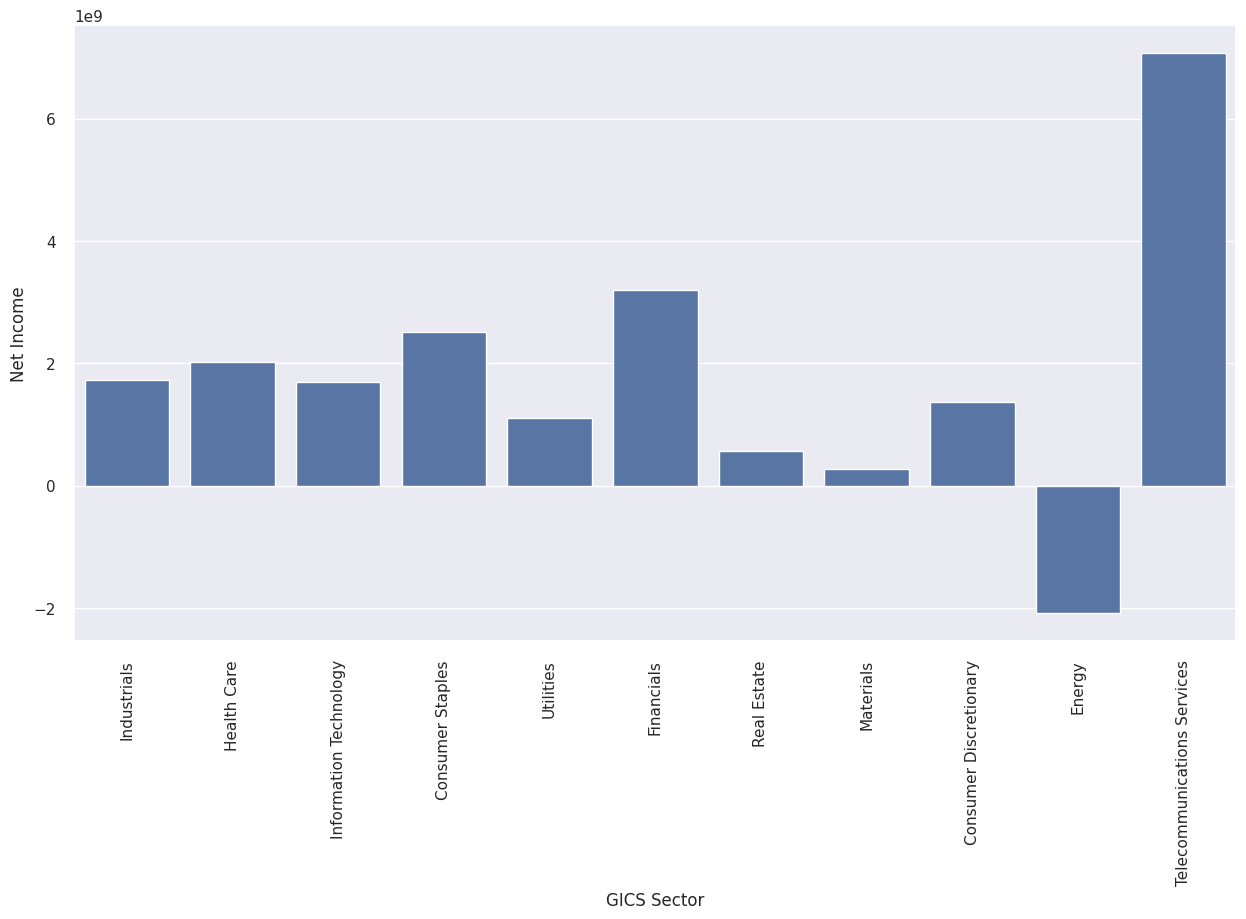

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df, x='GICS Sector', y='Net Income', ci=False)
plt.xticks(rotation=90)
plt.show()


**Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. Let's see how the average cash ratio varies across economic sectors.**

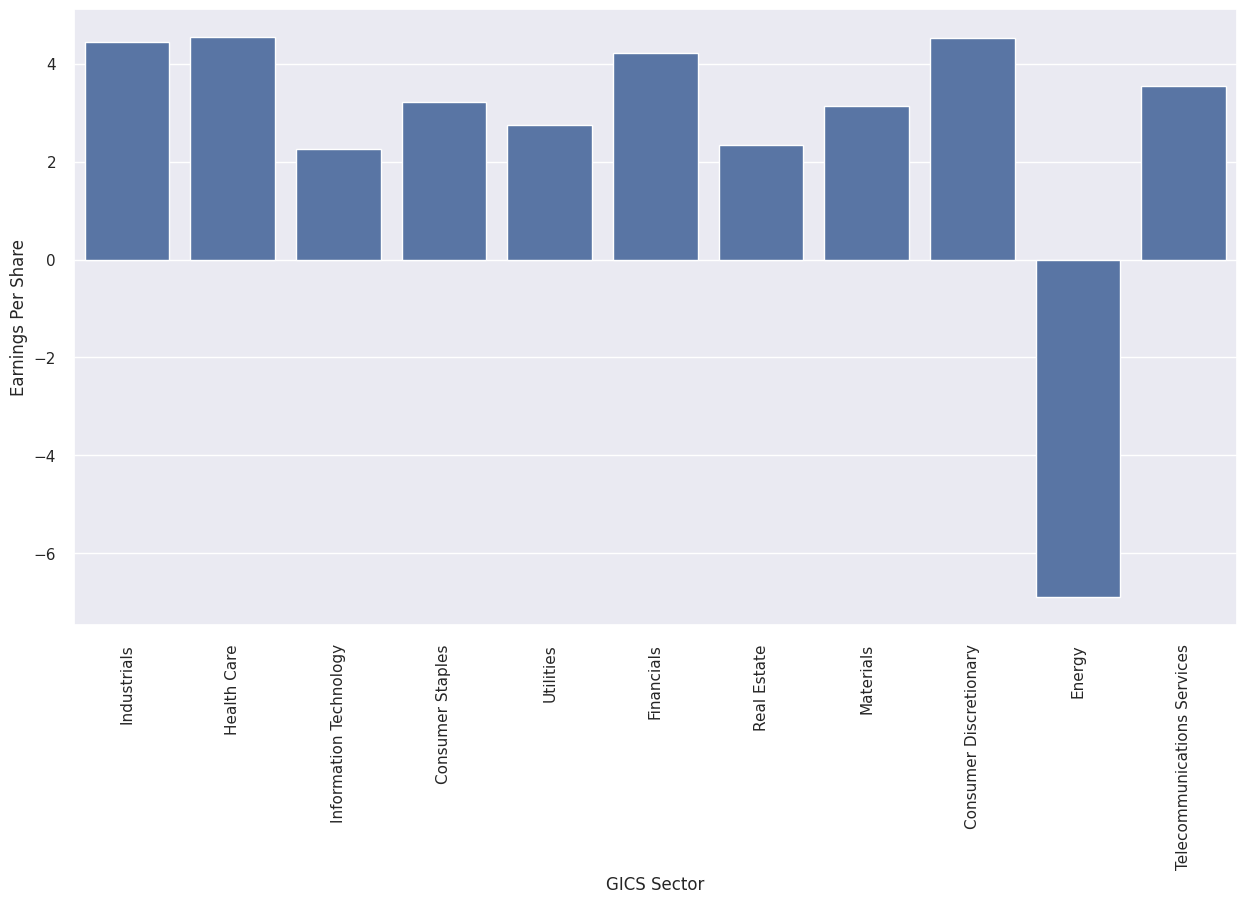

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df, x='GICS Sector', y='Earnings Per Share', ci=False)
plt.xticks(rotation=90)
plt.show()


**P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. Let's see how the P/E ratio varies, on average, across economic sectors.**

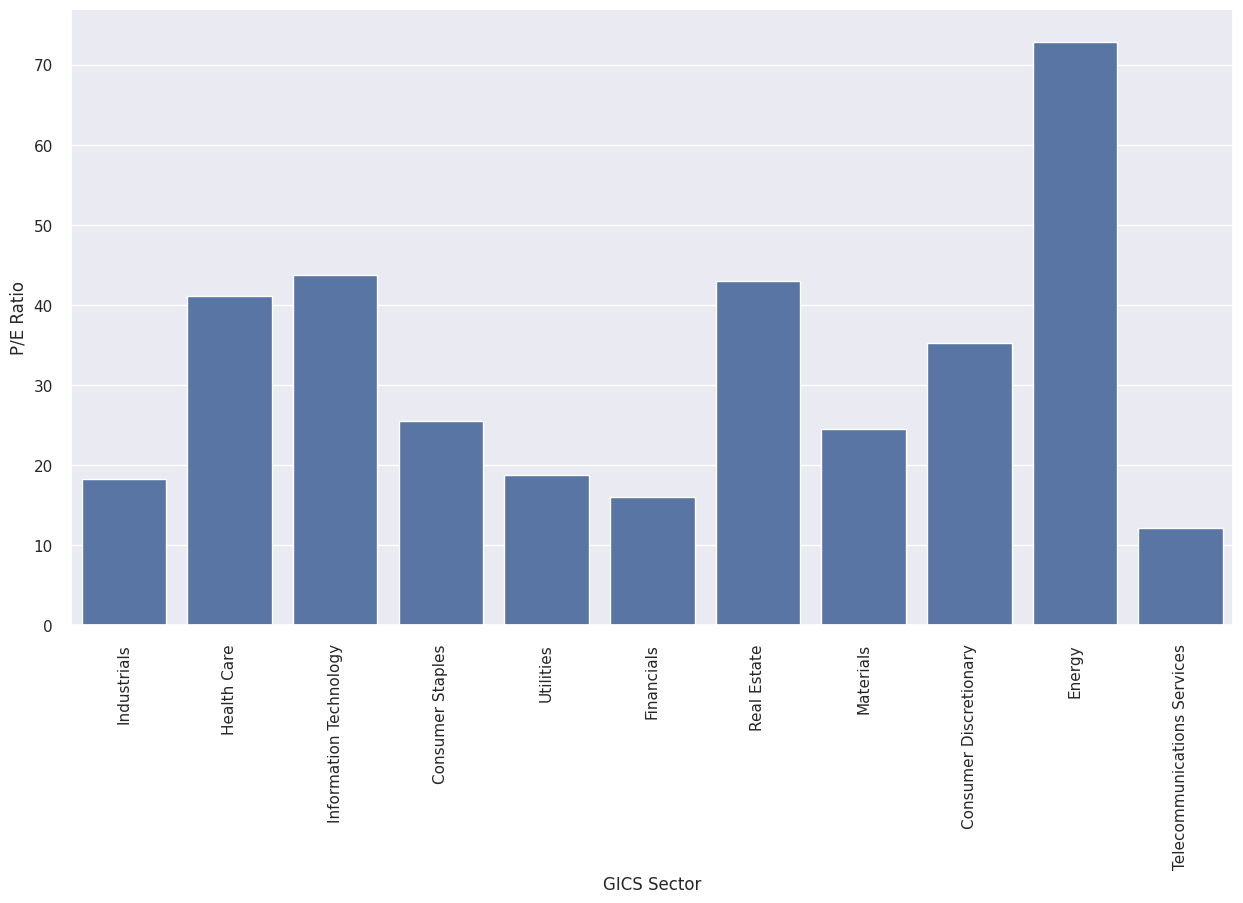

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df, x='GICS Sector', y='P/E Ratio', ci=False)
plt.xticks(rotation=90)
plt.show()


**Volatility accounts for the fluctuation in the stock price. A stock with high volatility will witness sharper price changes, making it a riskier investment. Let's see how volatility varies, on average, across economic sectors.**

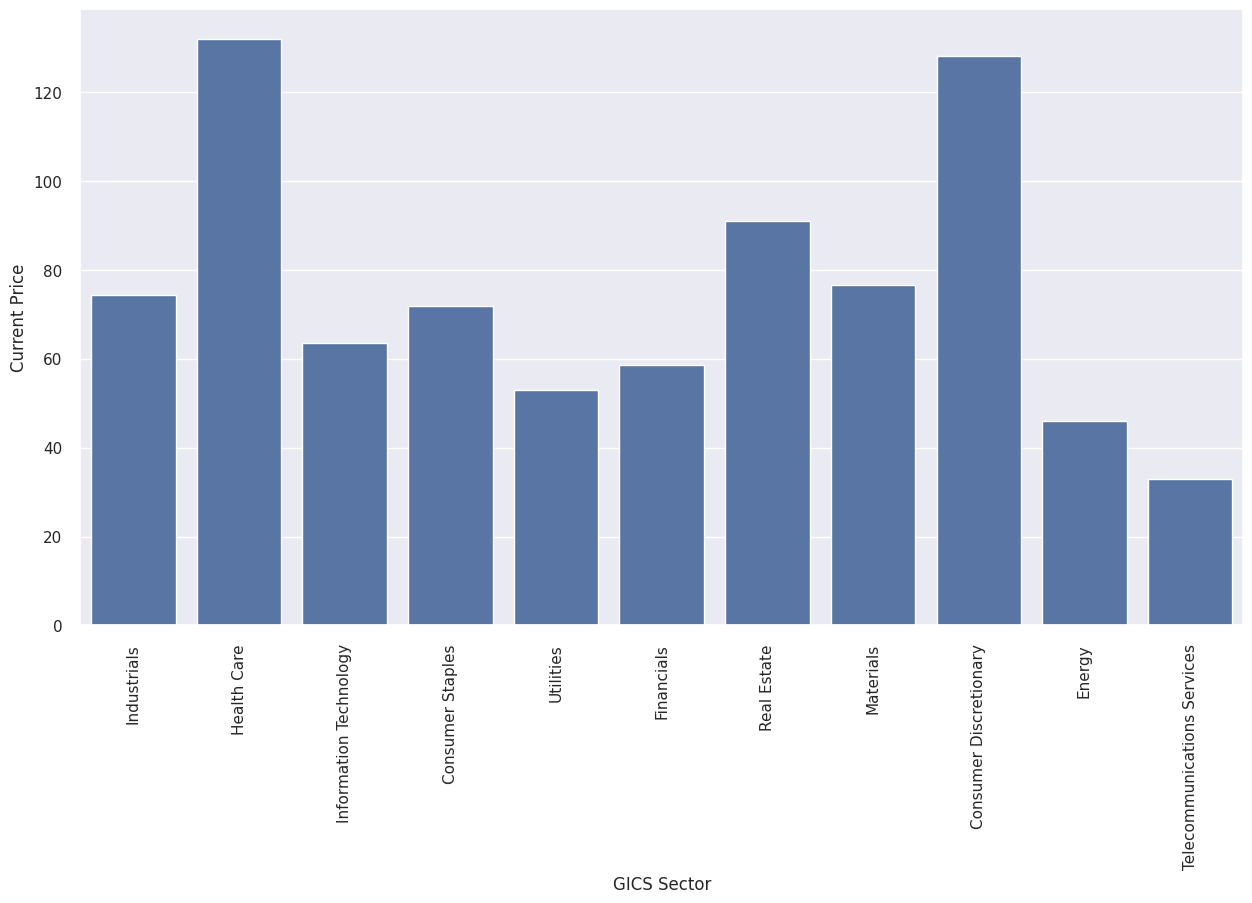

In [ ]:
plt.figure(figsize=(15,8))
sns.barplot(data=df, x='GICS Sector', y='Current Price', ci=False)
plt.xticks(rotation=90)
plt.show()


**Questions**:

1. What does the distribution of stock prices look like?


The distribution of stock prices is not directly visualized; however, the 'Current Price' bar chart could indicate that prices vary significantly across different sectors, with some sectors like Information Technology showing higher stock prices on average.

2. The stocks of which economic sector have seen the maximum price increase on average?

This data is not directly shown in the provided visuals or dataset. To determine this, you would need to calculate the average 'Price Change' for each 'GICS Sector' and then compare them to find the maximum.

3. How are the different variables correlated with each other?
The correlation heatmap provides the following insights:

There is a moderate positive correlation between 'Current Price' and 'Earnings Per Share', which suggests that stocks with higher prices also tend to have higher earnings per share.
'Net Income' and 'Earnings Per Share' also show a strong positive correlation, indicating that companies with higher net income generally report higher earnings per share.
There is a moderate negative correlation between 'Price Change' and 'Volatility', potentially indicating that stocks with greater price increases over the past 13 weeks were less volatile during that period.
'P/E Ratio' shows little correlation with most other variables, suggesting that the price investors are willing to pay for a dollar of earnings does not strongly depend on these financial metrics in this dataset.

4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?

The 'Cash Ratio' histogram indicates a wide distribution with a concentration of companies holding a ratio under 200, with a significant number of outliers that have much higher ratios. However, the bar chart for average 'Cash Ratio' by 'GICS Sector' is not provided, so we cannot determine how this varies across sectors.

5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

The 'P/E Ratio' histogram suggests a concentration of companies with lower P/E ratios, but with outliers that have very high P/E ratios, which could indicate overvaluation or high growth expectations. The bar chart showing 'P/E Ratio' by 'GICS Sector' indicates that sectors like Consumer Discretionary, Industrials, and Health Care have higher average P/E ratios, while sectors like Energy and Telecommunication Services have lower average P/E ratios, potentially reflecting varying investor expectations about growth and valuation across these sectors.

Additional Observations

The 'GICS Sector' bar chart with percentages indicates the proportion of companies within each sector in the dataset, with Industrials and Information Technology being the most represented sectors. The 'Net Income' bar chart across 'GICS Sectors' suggests that some sectors, like Consumer Discretionary and Information Technology, have higher net income on average, while others like Energy and Telecommunications Services have lower or even negative average net income, which could reflect the profitability and financial health of the sectors. The second, very wide bar chart seems to represent counts of companies within each 'GICS Sub Industry', indicating the distribution and diversity of the companies within the dataset.

## Data Preprocessing

### Outlier Check

- Let's plot the boxplots of all numerical columns to check for outliers.

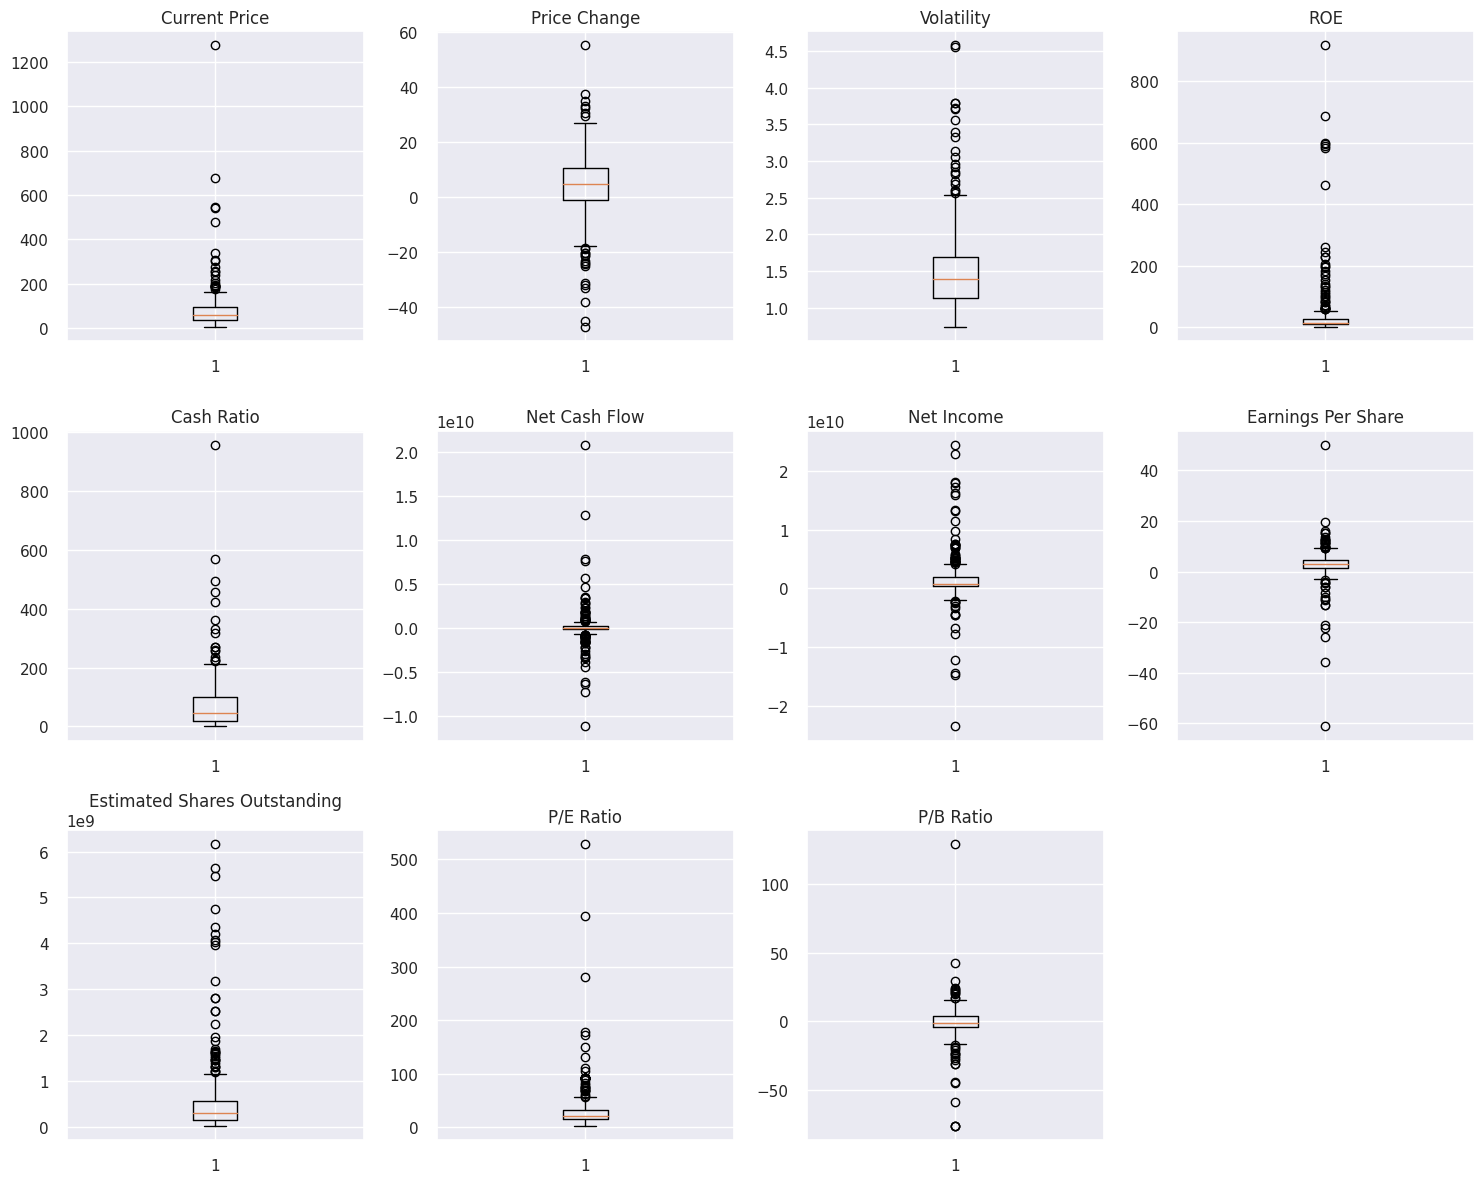

In [ ]:
plt.figure(figsize=(15, 12))

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define the columns you want to scale
selected_columns = ['Net Income', 'Earnings Per Share', 'P/E Ratio', 'Current Price']

# Create the subset of the dataframe you wish to scale using the selected columns
subset = df[selected_columns]

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the subset and transform the data
subset_scaled = scaler.fit_transform(subset)

# Create a DataFrame from the scaled data, using the same column names as the original subset
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)


## K-means Clustering

### Checking Elbow Plot

In [ ]:
k_means_df = subset_scaled_df.copy()

Number of Clusters: 1 	Average Distortion: 1.2240926937249303
Number of Clusters: 2 	Average Distortion: 1.1227476230952487
Number of Clusters: 3 	Average Distortion: 1.0815191743749604
Number of Clusters: 4 	Average Distortion: 1.0294363377348053
Number of Clusters: 5 	Average Distortion: 0.9417487388269714
Number of Clusters: 6 	Average Distortion: 0.8672474447210425
Number of Clusters: 7 	Average Distortion: 0.7697938941924904
Number of Clusters: 8 	Average Distortion: 0.6984828759000785
Number of Clusters: 9 	Average Distortion: 0.6588799538431053
Number of Clusters: 10 	Average Distortion: 0.6389933200568084
Number of Clusters: 11 	Average Distortion: 0.5846822574612881
Number of Clusters: 12 	Average Distortion: 0.5782841875142658
Number of Clusters: 13 	Average Distortion: 0.5588003277489926
Number of Clusters: 14 	Average Distortion: 0.5212325113609643


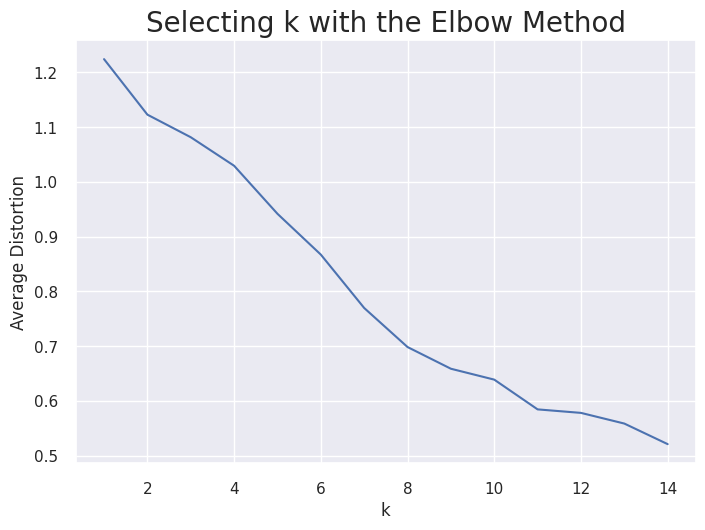

In [ ]:
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis=1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

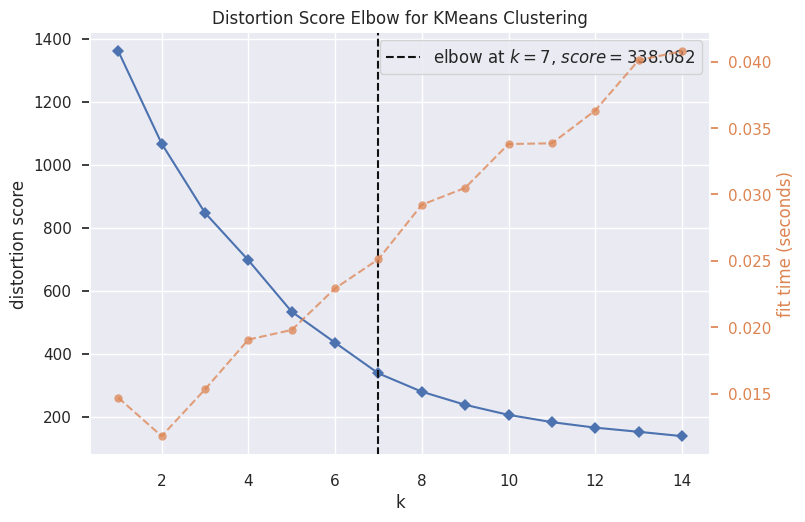

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1, 15), timings=True)
visualizer.fit(k_means_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

### Let's check the silhouette scores

For n_clusters = 2, the silhouette score is 0.6310220837708257)
For n_clusters = 3, the silhouette score is 0.6837234322430775)
For n_clusters = 4, the silhouette score is 0.6832902149912613)
For n_clusters = 5, the silhouette score is 0.5763601226763561)
For n_clusters = 6, the silhouette score is 0.6038135869589487)
For n_clusters = 7, the silhouette score is 0.51077427485122)
For n_clusters = 8, the silhouette score is 0.42699006245542753)
For n_clusters = 9, the silhouette score is 0.43453778313128116)
For n_clusters = 10, the silhouette score is 0.436909804498287)
For n_clusters = 11, the silhouette score is 0.3441698217352033)
For n_clusters = 12, the silhouette score is 0.43027048792614886)
For n_clusters = 13, the silhouette score is 0.42158980329858925)
For n_clusters = 14, the silhouette score is 0.32013634588257905)


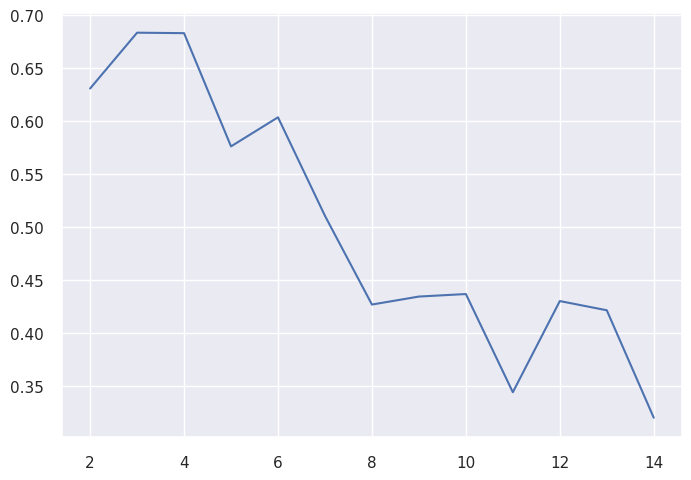

In [ ]:
sil_score = []
cluster_list = range(2, 15)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

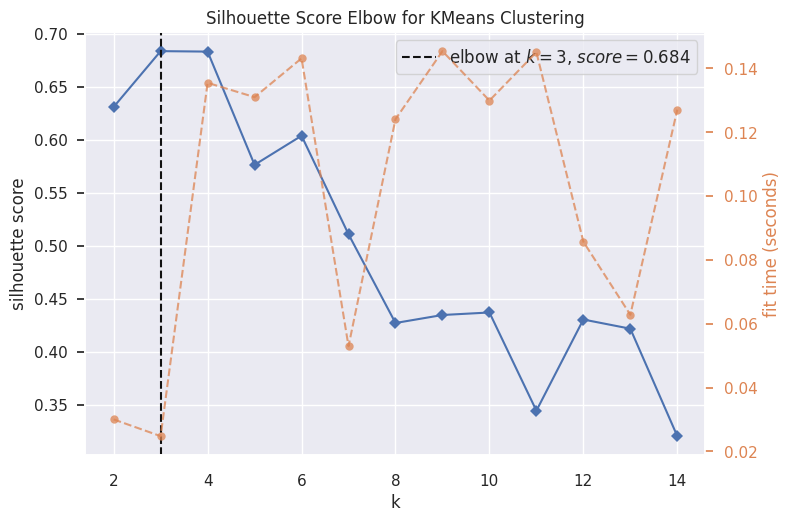

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 15), metric="silhouette", timings=True)
visualizer.fit(k_means_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

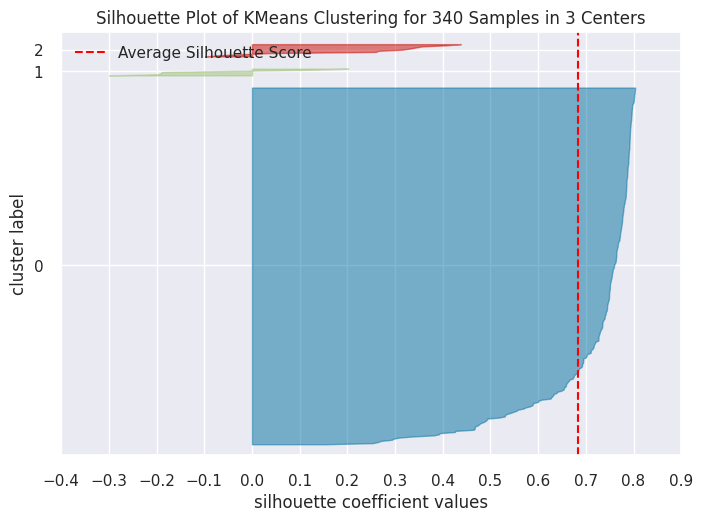

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

# Assuming k_means_df is your data prepared for K-Means
# and that you've found k=3 to be optimal from the silhouette score elbow method

# Initialize the KMeans model with the optimal number of clusters
model = KMeans(n_clusters=3, random_state=1)

# Initialize the Silhouette Visualizer with the KMeans model
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer
visualizer.fit(k_means_df)

# Display the visualization
visualizer.show()


### Creating Final Model

In [ ]:
# Assuming 5 is the optimal number of clusters identified
kmeans = KMeans(n_clusters=5, random_state=1)  # Replace '___' with the chosen number of clusters
kmeans.fit(k_means_df)


KMeans(n_clusters=5, random_state=1)

In [ ]:
# creating a copy of the original data
df1 = df.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_



```
```

### Cluster Profiling

In [ ]:
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,KM_segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,2
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,0
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,0
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,0
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,0


In [ ]:
for col in df1.columns:
    non_numeric_values = df1[col].apply(lambda x: not pd.to_numeric(x, errors='ignore'))
    if non_numeric_values.any():
        print(f"Column '{col}' contains non-numeric values:")
        print(df1[col][non_numeric_values])

Column 'Cash Ratio' contains non-numeric values:
64     0
76     0
190    0
267    0
Name: Cash Ratio, dtype: int64
Column 'KM_segments' contains non-numeric values:
1      0
2      0
3      0
4      0
5      0
      ..
335    0
336    0
337    0
338    0
339    0
Name: KM_segments, Length: 307, dtype: int32


In [ ]:
df1.dtypes

Ticker Symbol                    object
Security                         object
GICS Sector                      object
GICS Sub Industry                object
Current Price                   float64
Price Change                    float64
Volatility                      float64
ROE                               int64
Cash Ratio                        int64
Net Cash Flow                     int64
Net Income                        int64
Earnings Per Share              float64
Estimated Shares Outstanding    float64
P/E Ratio                       float64
P/B Ratio                       float64
KM_segments                     float64
dtype: object

In [ ]:
# Check the data types of the columns in the 'df1' dataframe.
print(df1.dtypes)

# Check the unique values present in the 'KM_segments' column.
print(df1['KM_segments'].unique())

Ticker Symbol                    object
Security                         object
GICS Sector                      object
GICS Sub Industry                object
Current Price                   float64
Price Change                    float64
Volatility                      float64
ROE                               int64
Cash Ratio                        int64
Net Cash Flow                     int64
Net Income                        int64
Earnings Per Share              float64
Estimated Shares Outstanding    float64
P/E Ratio                       float64
P/B Ratio                       float64
KM_segments                     float64
dtype: object
[2. 4. 1. 3.]


In [ ]:
df1.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,KM_segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,2.0
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,0.0
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,0.0
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,0.0
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,0.0


In [ ]:
for cl in df1["KM_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1[df1["KM_segments"] == cl]["Security"].unique())
    print()

In cluster 1, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Archer-Daniels-Midland Co' 'Ameren Corp'
 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Ameriprise Financial' 'American Tower Corp A' 'AutoNation Inc'
 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'The Bank of New York Mellon Corp.' 'Ball Corp' 'Bristol-Myers Squibb'
 'Boston Scientific' 'BorgWarner' 'Boston Properties' 'Caterpillar Inc.'
 'Chubb Limited' 'CBRE Group' 'Crown Castl

In [ ]:
df1.groupby(["KM_segments", "GICS Sector"])['Security'].count()

KM_segments  GICS Sector                
0            Consumer Discretionary          1
             Energy                         21
             Health Care                     1
             Industrials                     1
             Information Technology          4
             Materials                       2
1            Consumer Discretionary         33
             Consumer Staples               17
             Energy                          5
             Financials                     45
             Health Care                    29
             Industrials                    52
             Information Technology         24
             Materials                      18
             Real Estate                    26
             Telecommunications Services     2
             Utilities                      24
2            Consumer Discretionary          5
             Consumer Staples                1
             Financials                      1
             Health

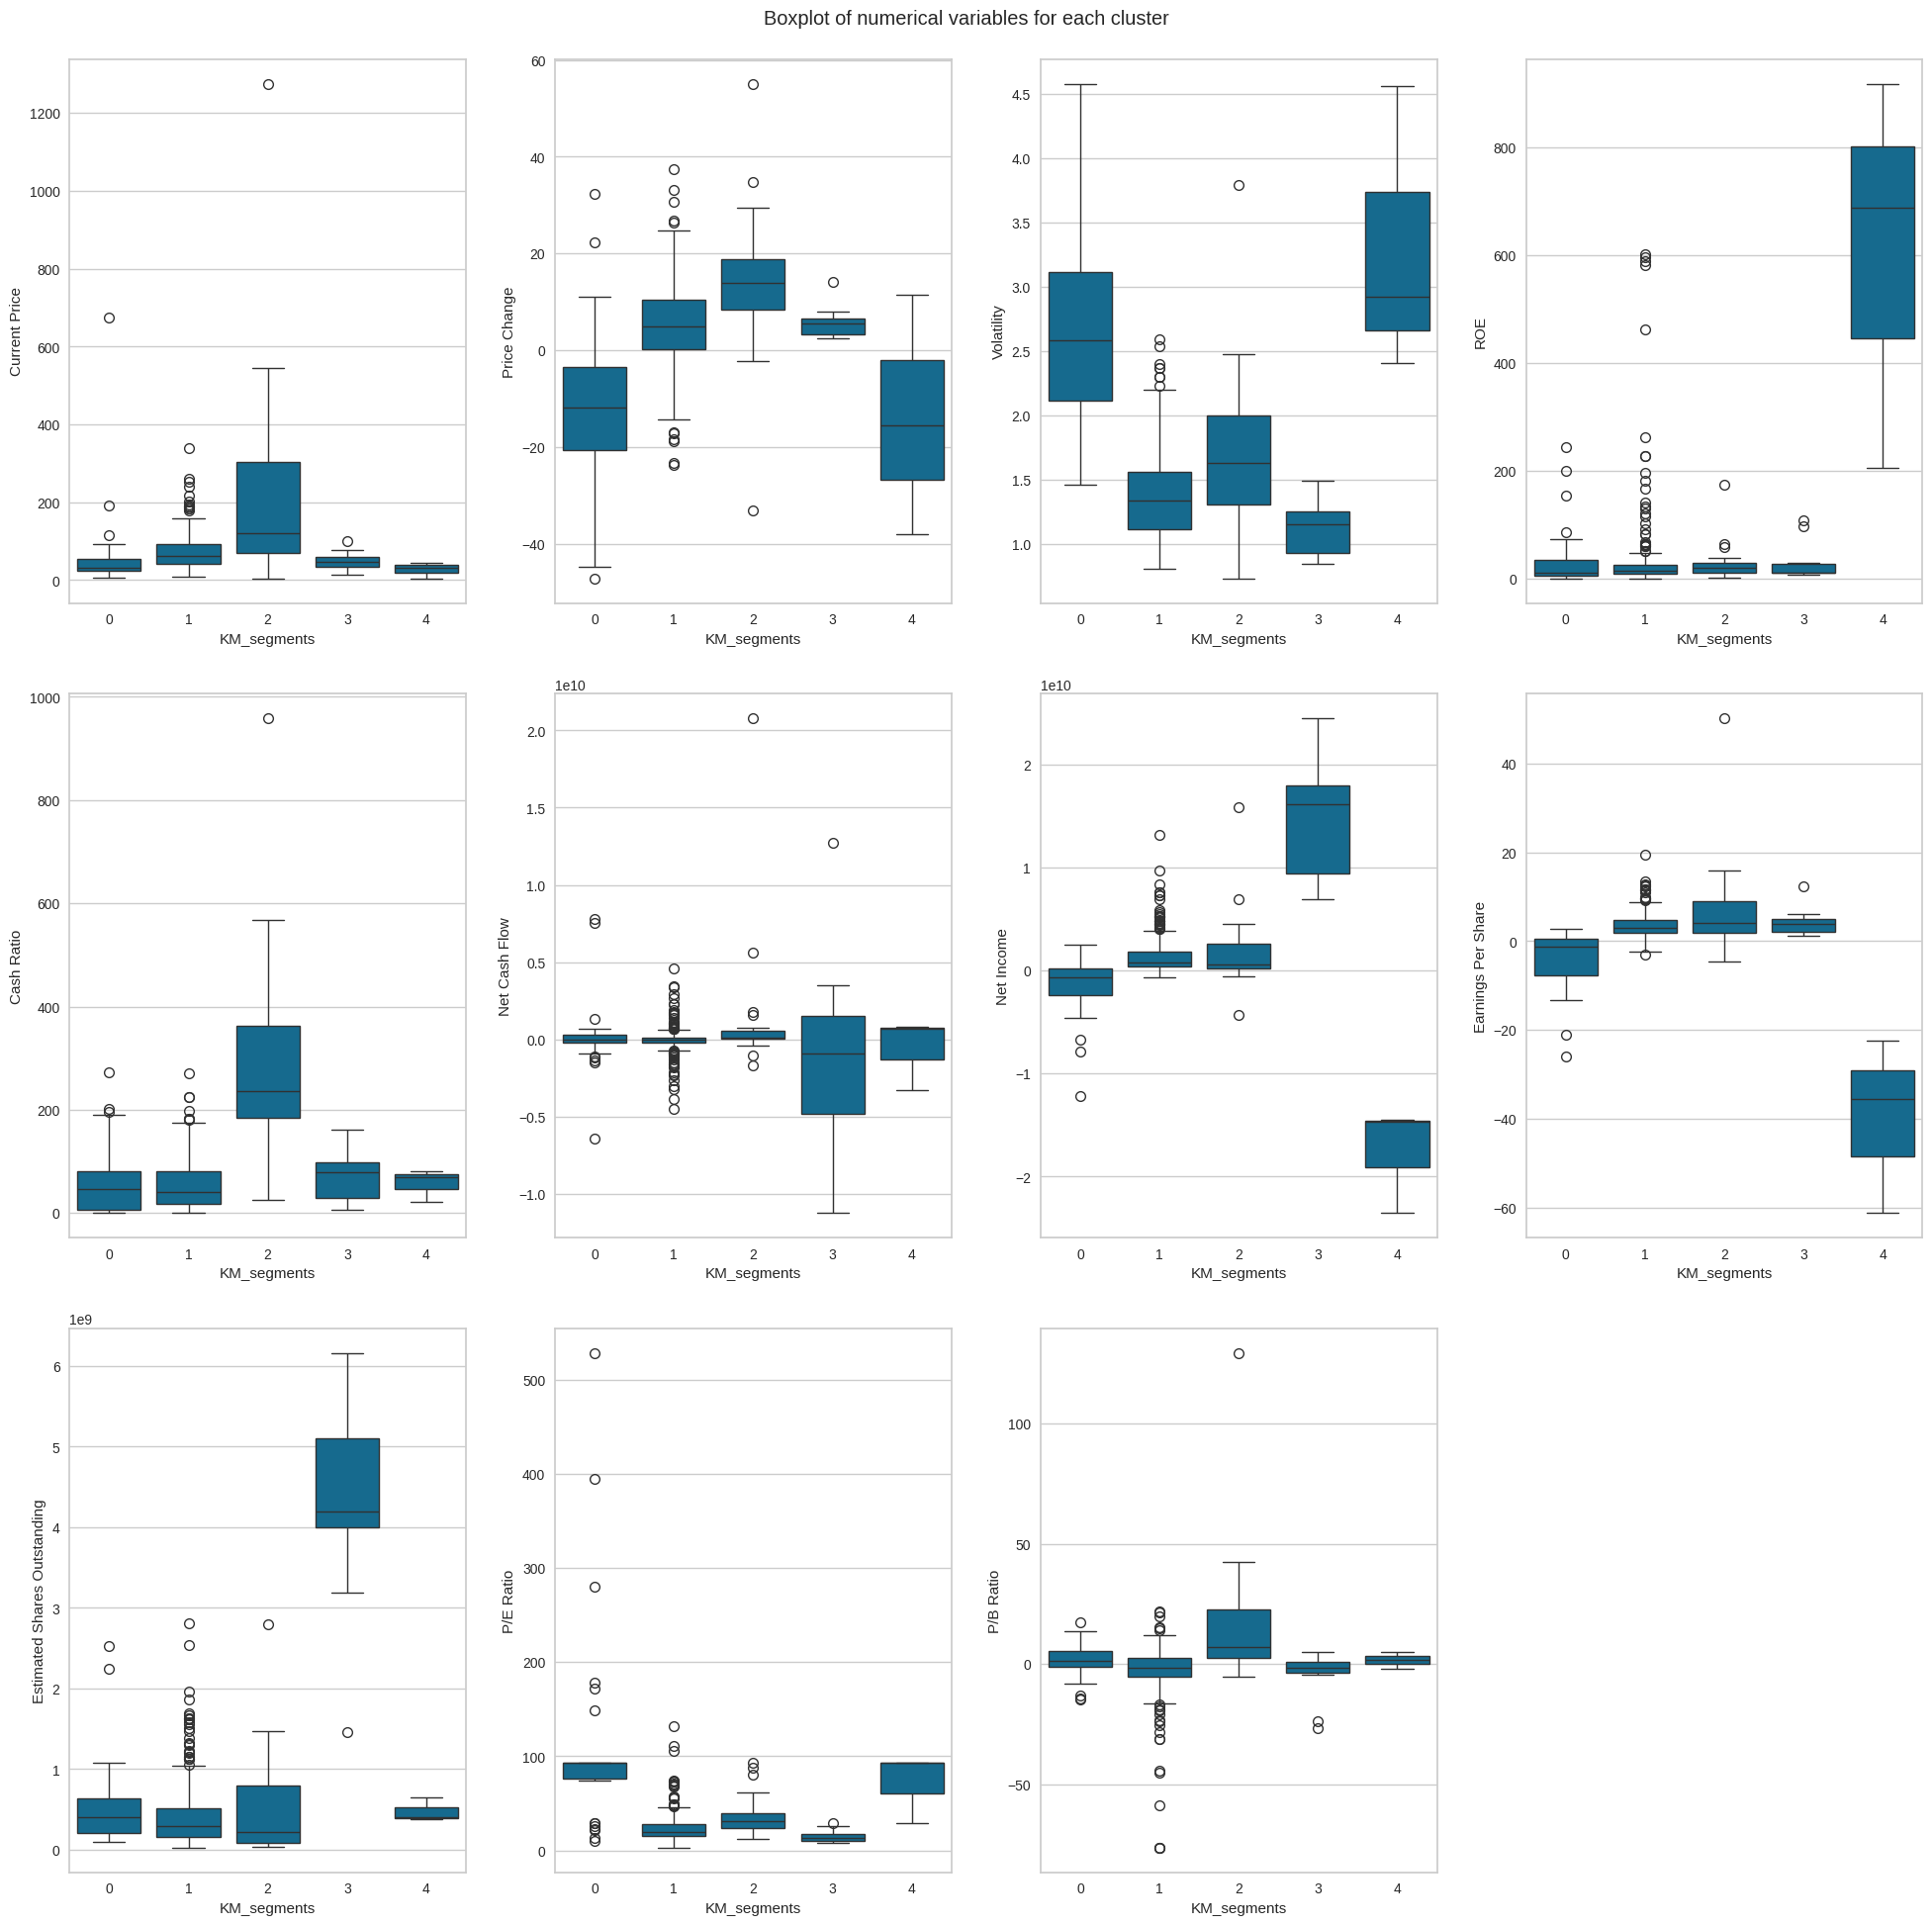

In [ ]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(num_col):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1, x="KM_segments", y=variable)

plt.tight_layout(pad=2.0)

### Insights

-


## Hierarchical Clustering

### Computing Cophenetic Correlation

In [ ]:
hc_df = subset_scaled_df.copy()

In [ ]:
!pip install scipy
!pip install pandas

In [ ]:
import scipy.cluster.hierarchy as sch
import pandas as pd

In [ ]:
distance_metrics = ['euclidean', 'cityblock', 'chebyshev', 'minkowski']

In [ ]:
!pip install scipy

In [ ]:
import scipy.cluster.hierarchy as sch
import numpy as np

In [ ]:
for dm in distance_metrics:
    for lm in ['average', 'single']:
        Z = sch.linkage(hc_df, metric=dm, method=lm)
        c, coph_dists = sch.cophenet(Z, pdist(hc_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Cityblock distance and average linkage is 0.9302145048594667.
Cophenetic correlation for Cityblock distance and single linkage is 0.9334186366528574.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338265528030499.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9062538164750717.
Cophenetic correlation for Minkowski distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Minkowski distance and single linkage is 0.9232271494002922.


In [ ]:
distance_metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']  ## Adding distance metrics
linkage_methods = ['single', 'complete', 'average', 'ward']  ## Adding linkage methods


In [ ]:
linkage_methods = ['single', 'complete', 'average', 'ward']  ## Reiterating linkage methods


**Let's explore different linkage methods with Euclidean distance only.**

In [ ]:
# No need to re-install packages in most environments, but ensure they are imported
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import numpy as np
import pandas as pd

# Copying your scaled data for hierarchical clustering
hc_df = subset_scaled_df.copy()

# Initializing variables to track the highest cophenetic correlation and the corresponding distance metric and linkage method
high_cophenet_corr = 0
high_dm_lm = ['', '']

# Specifying distance metrics and linkage methods to explore
distance_metrics = ['euclidean', 'cityblock', 'chebyshev', 'minkowski']
linkage_methods = ['average', 'single']

# Looping through combinations of distance metrics and linkage methods
for dm in distance_metrics:
    for lm in linkage_methods:
        Z = sch.linkage(hc_df, metric=dm, method=lm)
        c, coph_dists = sch.cophenet(Z, pdist(hc_df))
        print(f"Cophenetic correlation for {dm.capitalize()} distance and {lm} linkage is {c}.")
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm = [dm, lm]

# Printing the combination with the highest cophenetic correlation
print('*'*100)
print(f"Highest cophenetic correlation is {high_cophenet_corr}, obtained with {high_dm_lm[0].capitalize()} distance and {high_dm_lm[1]} linkage.")


Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Cityblock distance and average linkage is 0.9302145048594667.
Cophenetic correlation for Cityblock distance and single linkage is 0.9334186366528574.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338265528030499.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9062538164750717.
Cophenetic correlation for Minkowski distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Minkowski distance and single linkage is 0.9232271494002922.
****************************************************************************************************
Highest cophenetic correlation is 0.9422540609560814, obtained with Euclidean distance and average linkage.


**Let's view the dendrograms for the different linkage methods with Euclidean distance.**

### Checking Dendrograms

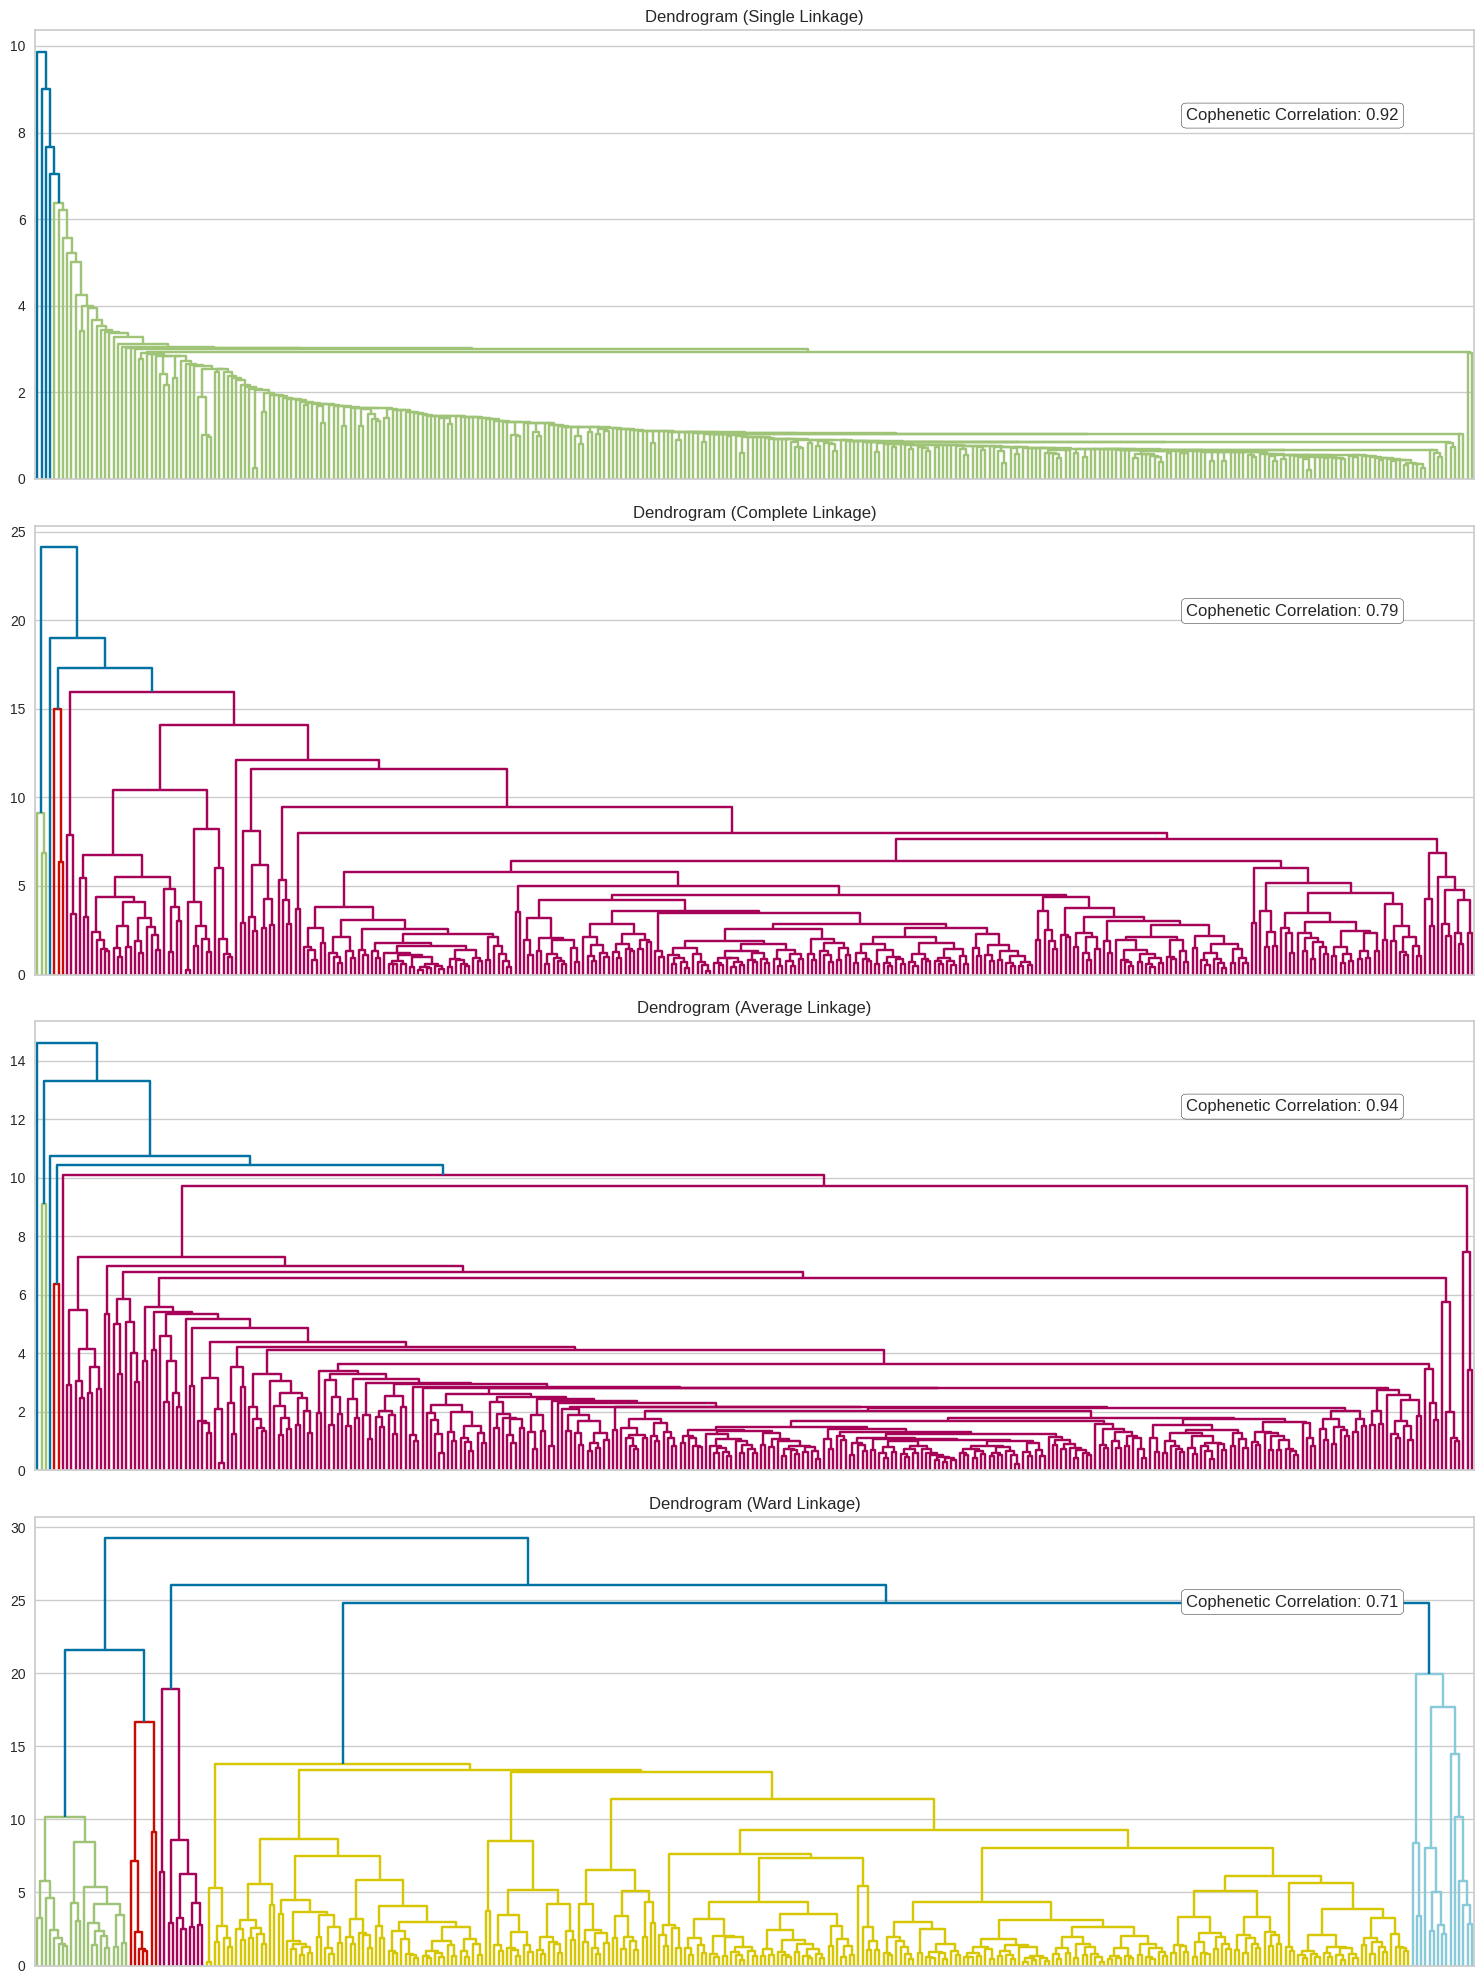

    Linkage  Cophenetic Coefficient
0    single                0.923227
1  complete                0.787328
2   average                0.942254
3      ward                0.710118


In [ ]:
# Completing the code to add linkages
linkage_methods = ['single', 'complete', 'average', 'ward']

# Lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# Importing necessary libraries for plotting
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

# Creating a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 5 * len(linkage_methods)))

# Checking if only one plot is needed, adjust figure if necessary
if len(linkage_methods) == 1:
    axs = [axs]

# We will enumerate through the list of linkage methods above
for i, method in enumerate(linkage_methods):
    Z = linkage(hc_df, metric="euclidean", method=method)

    # Plotting the dendrogram for each linkage method
    dendrogram(Z, ax=axs[i], no_labels=True)
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    # Calculating the cophenetic correlation for each linkage method
    coph_corr, coph_dist = cophenet(Z, pdist(hc_df))
    axs[i].annotate(
        f"Cophenetic Correlation: {coph_corr:0.2f}",
        xy=(0.80, 0.80),
        xycoords="axes fraction",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"),
    )

    # Saving the results for comparison
    compare.append([method, coph_corr])

# Adjust layout
plt.tight_layout()
plt.show()

# Converting comparison results to DataFrame for better readability
import pandas as pd
comparison_df = pd.DataFrame(compare, columns=compare_cols)
print(comparison_df)


In [ ]:
# create and print a dataframe to compare cophenetic correlations for different linkage methods
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc = df_cc.sort_values(by="Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
3,ward,0.710118
1,complete,0.787328
0,single,0.923227
2,average,0.942254


### Creating model using sklearn

In [ ]:
HCmodel = AgglomerativeClustering(n_clusters='___', affinity='___', linkage='___')  ## Complete the code to define the hierarchical clustering model
HCmodel.fit(hc_df)

In [ ]:
# creating a copy of the original data
df2 = df.copy()

# adding hierarchical cluster labels to the original and scaled dataframes
hc_df["HC_segments"] = HCmodel.labels_
df2["HC_segments"] = HCmodel.labels_

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Assuming the analysis suggests 5 clusters, using "euclidean" affinity, and "ward" linkage is optimal
HCmodel = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
HCmodel.fit(hc_df)


AgglomerativeClustering(affinity='euclidean', n_clusters=5)

In [ ]:
# Creating a copy of the original data
df2 = df.copy()

# Adding hierarchical cluster labels to the original and scaled dataframes
hc_df["HC_segments"] = HCmodel.labels_
df2["HC_segments"] = HCmodel.labels_


### Cluster Profiling

In [ ]:
hc_cluster_profile = df2.groupby("___").mean()  ## Complete the code to groupby the cluster labels

In [ ]:
hc_cluster_profile = df2.groupby("HC_segments").mean()

In [ ]:
hc_cluster_profile["count_in_each_segment"] = (
    df2.groupby("___")["Security"].count().values  ## Complete the code to groupby the cluster labels
)

In [ ]:
hc_cluster_profile["count_in_each_segment"] = df2.groupby("HC_segments")["Security"].count().values


In [ ]:
hc_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
HC_segments,,,,,,,,,,,,
0,326.198218,10.563242,1.642560,14.400000,309.466667,288850666.666667,864498533.333333,7.785333,544900261.301333,113.095334,19.142151,15
1,84.355716,3.854981,1.827670,633.571429,33.571429,-568400000.000000,-4968157142.857142,-10.841429,398169036.442857,42.284541,-11.589502,7
2,42.848182,6.270446,1.123547,22.727273,71.454545,558636363.636364,14631272727.272728,3.410000,4242572567.290909,15.242169,-4.924615,11
3,72.760400,5.213307,1.427078,25.603509,60.392982,79951512.280702,1538594322.807018,3.655351,446472132.228456,24.722670,-2.647194,285
4,36.440455,-16.073408,2.832884,57.500000,42.409091,-472834090.909091,-3161045227.272727,-8.005000,514367806.201818,85.555682,0.836839,22


In [ ]:
hc_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

In [ ]:
## Complete the code to print the companies in each cluster
for cl in df2["____"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2[df2["___"] == cl]["Security"].unique())
    print()

In [ ]:
# For printing companies in each cluster
for cl in df2["HC_segments"].unique():
    print(f"In cluster {cl}, the following companies are present:")
    print(df2[df2["HC_segments"] == cl]["Security"].unique())
    print()


In cluster 3, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Ameriprise Financial' 'American Tower Corp A' 'AutoNation Inc'
 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.' 'Ball Corp'
 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'Boston Properties' 'Caterpillar Inc.' 'Chubb Lim

In [ ]:
df2.groupby(["HC_segments", "GICS Sector"])['Security'].count()

HC_segments  GICS Sector                
0            Consumer Discretionary          3
             Consumer Staples                1
             Health Care                     5
             Information Technology          4
             Real Estate                     1
             Telecommunications Services     1
1            Consumer Discretionary          1
             Consumer Staples                2
             Energy                          2
             Financials                      1
             Industrials                     1
2            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      4
             Health Care                     1
             Information Technology          1
             Telecommunications Services     2
3            Consumer Discretionary         35
             Consumer Staples               15
             Energy

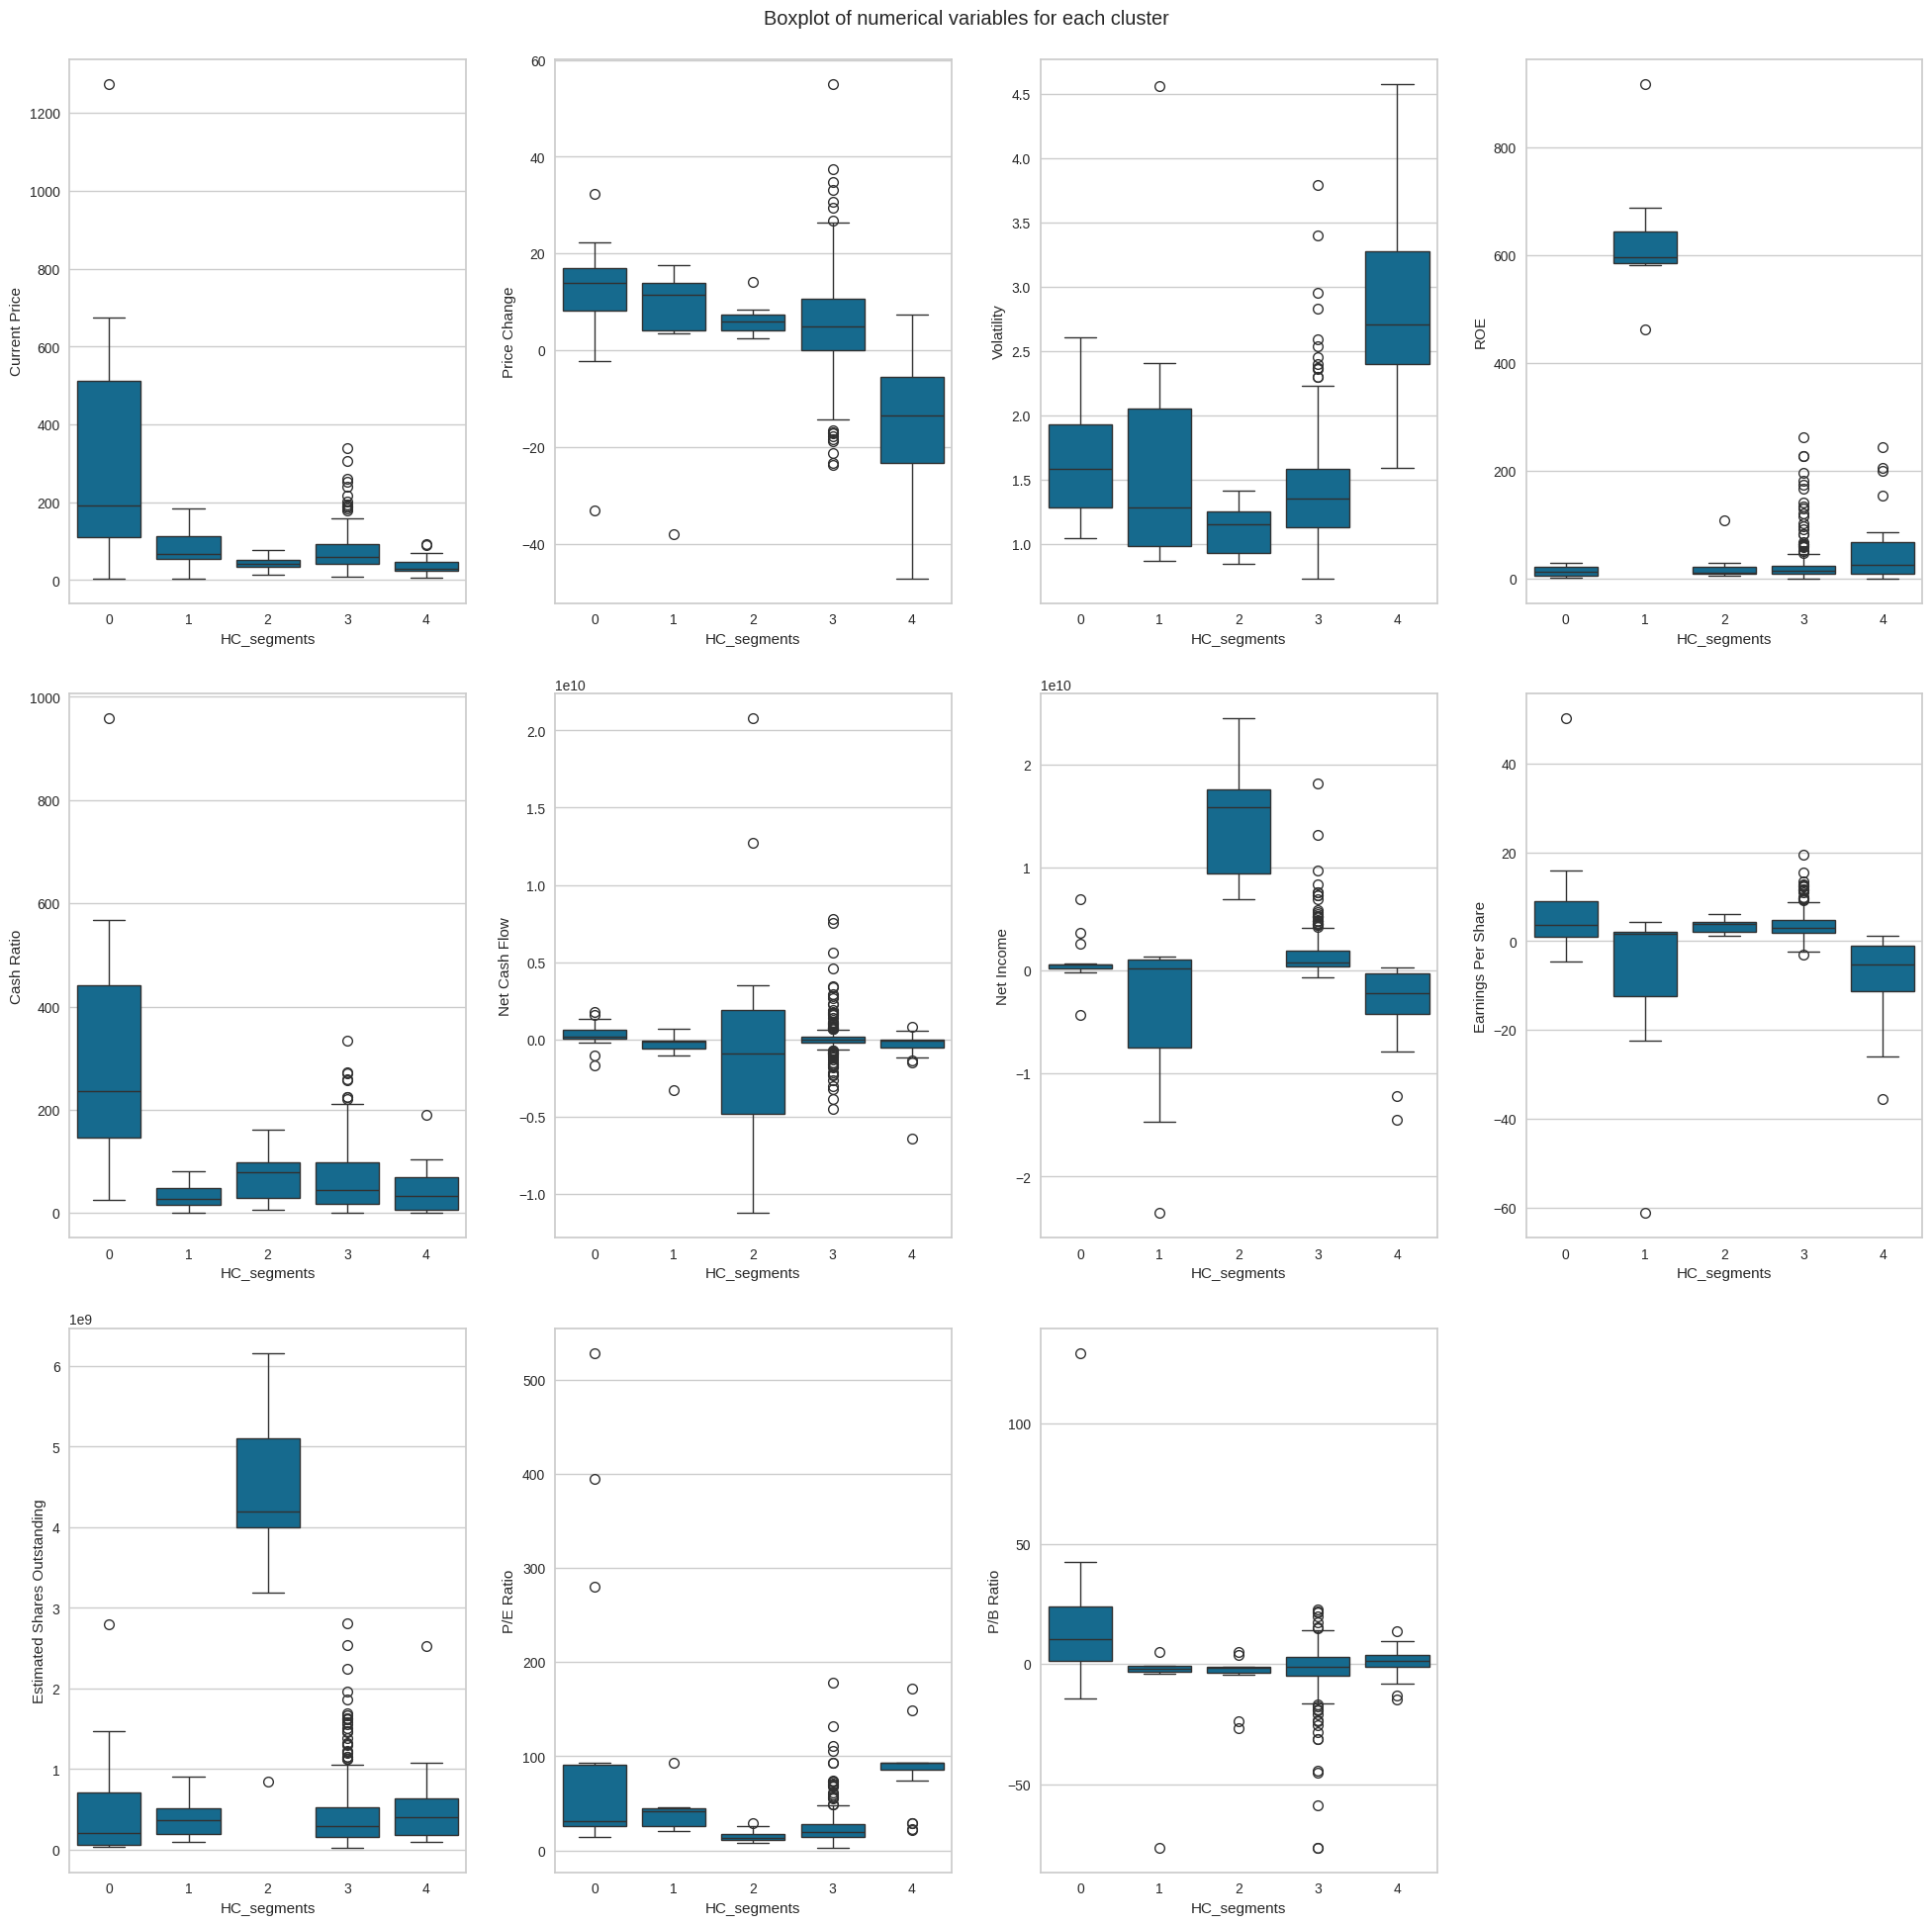

In [ ]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(num_col):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2, x="HC_segments", y=variable)

plt.tight_layout(pad=2.0)

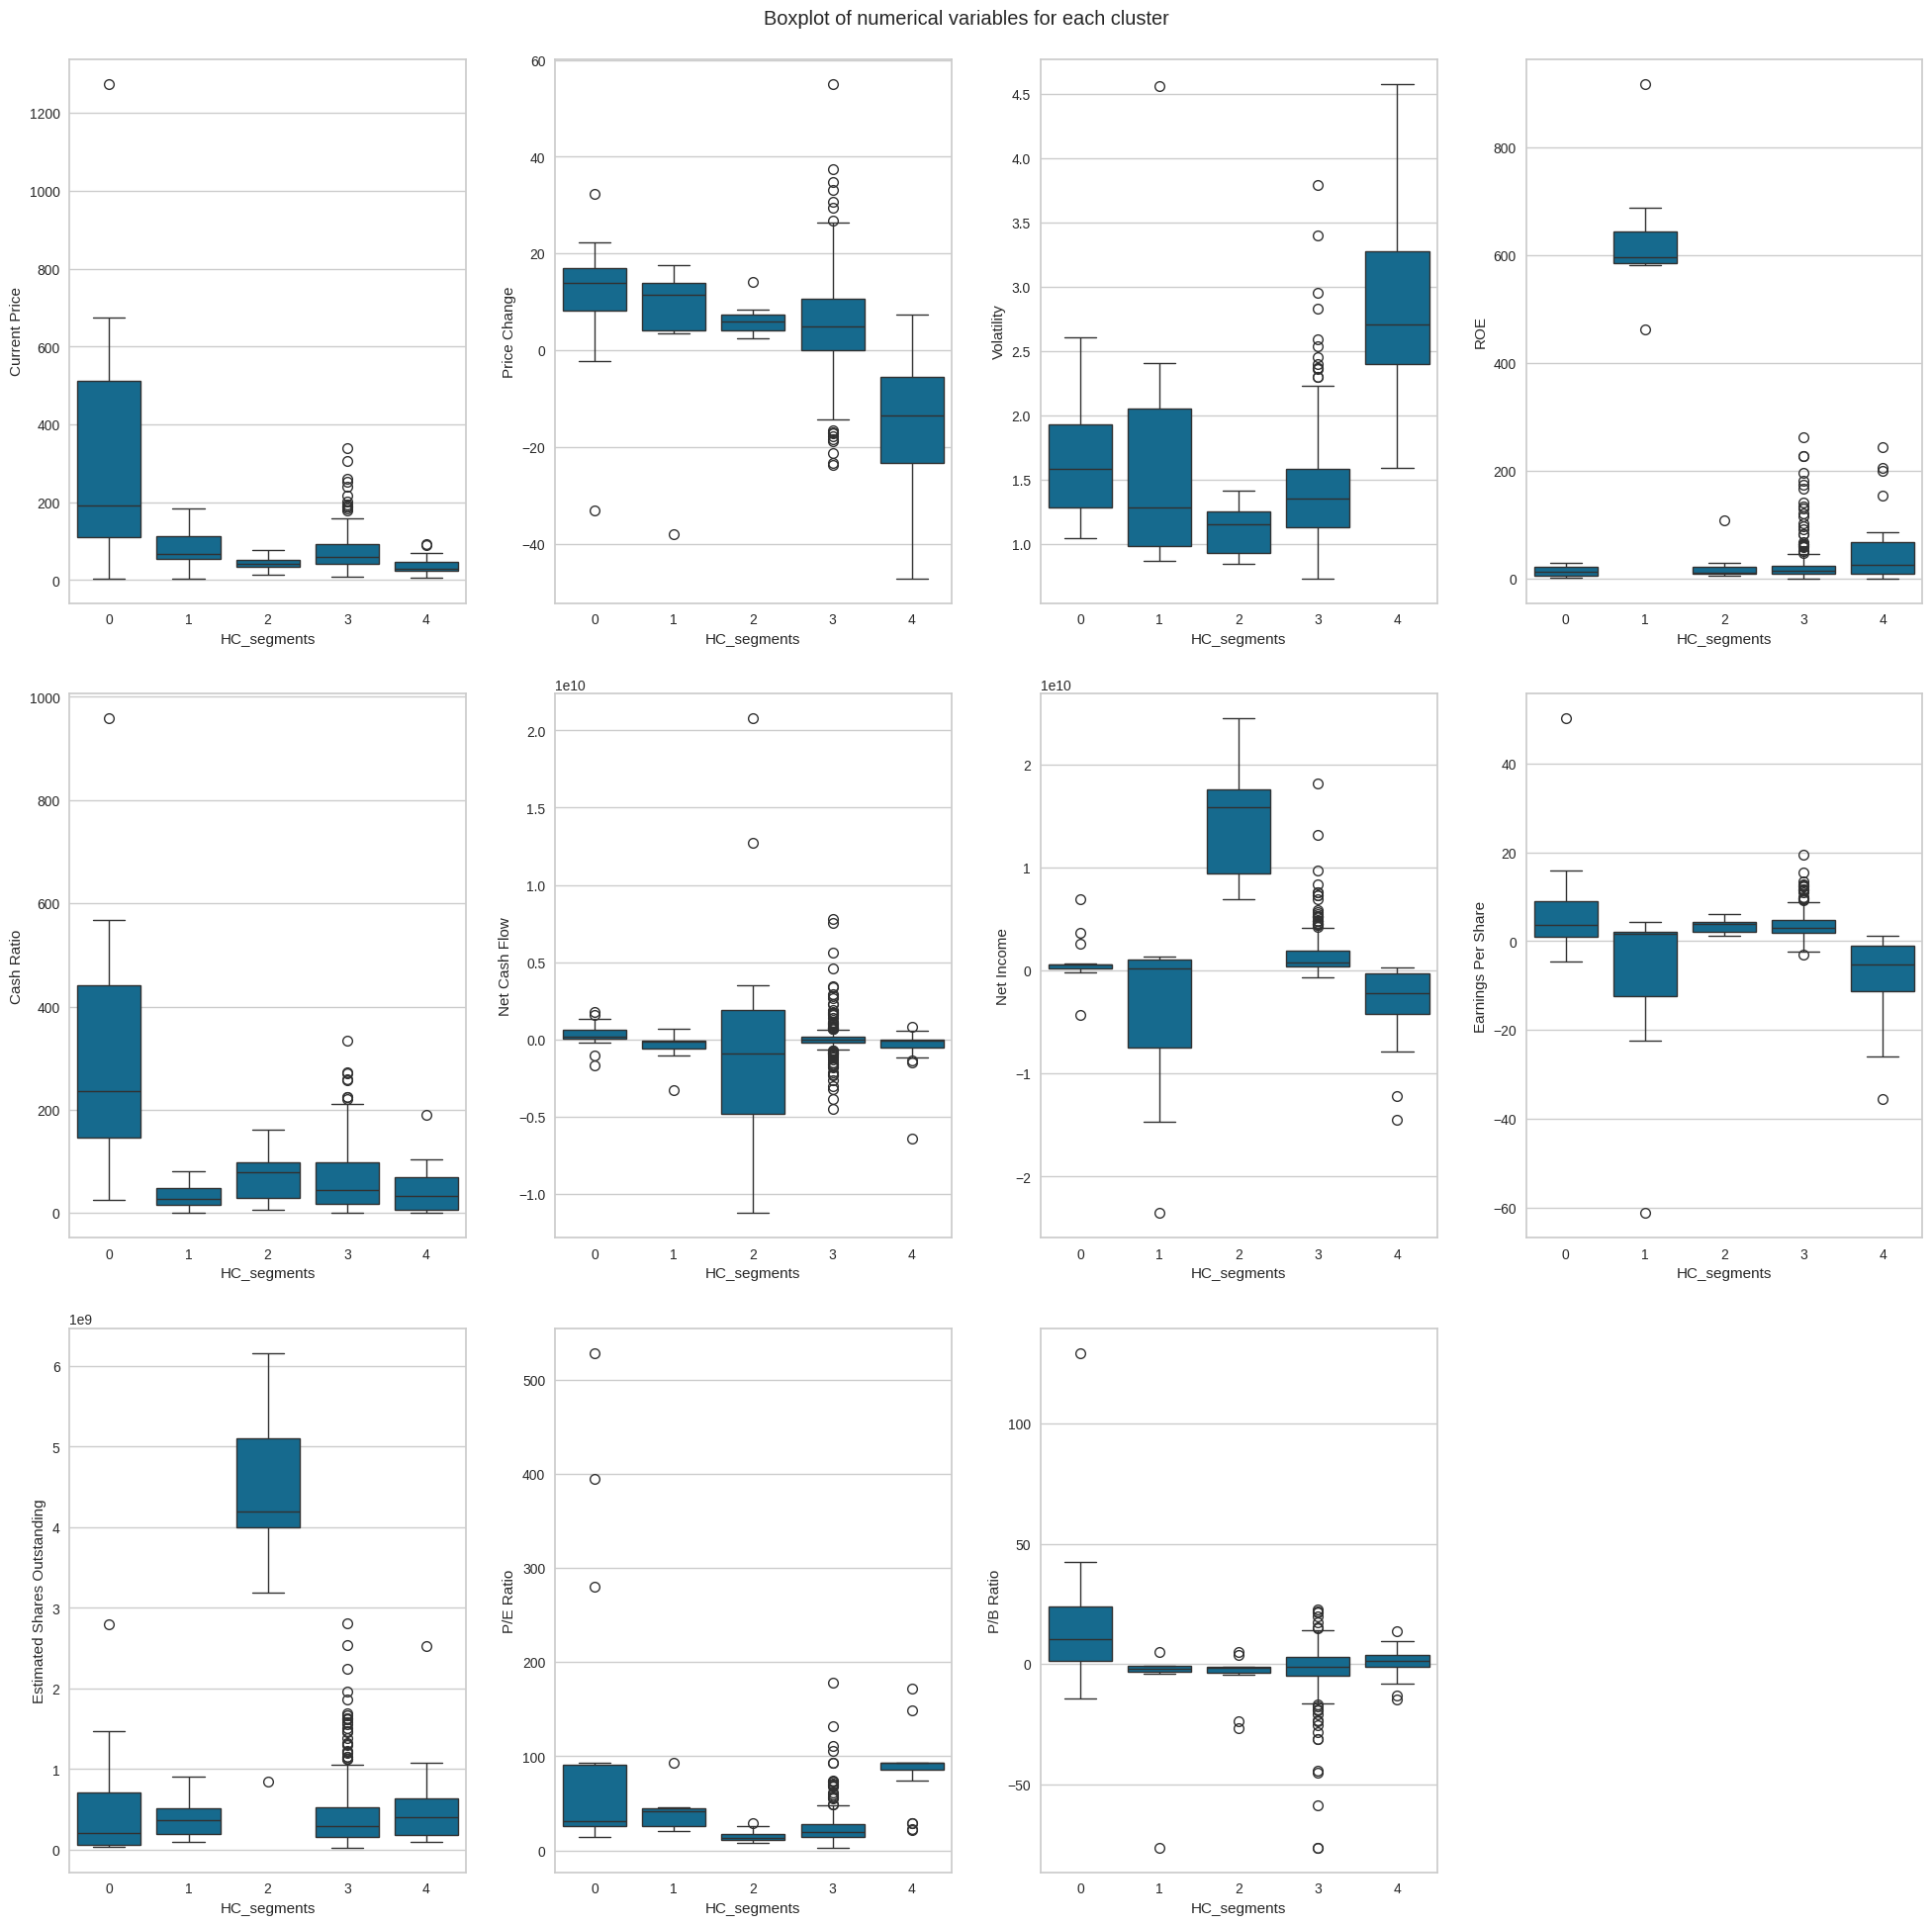

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

# Adjust the subplot dimensions based on the number of numerical variables
n_rows = (len(num_col) + 3) // 4  # Adjust rows to fit all subplots
for i, variable in enumerate(num_col):
    plt.subplot(n_rows, 4, i + 1)  # Adjust for the number of subplots needed
    sns.boxplot(data=df2, x="HC_segments", y=variable)

plt.tight_layout(pad=2.0)


## K-means vs Hierarchical Clustering

Comparison of K-Means and Hierarchical Clustering:

- Which clustering technique took less time for execution?

K-Means typically runs faster than hierarchical clustering, especially on large datasets. Hierarchical clustering requires computing and storing a distance matrix, which can be computationally intensive.

- Which clustering technique gave you more distinct clusters, or are they the same?

K-Means gave more distinct clusters with a clear grouping, as observed from the higher silhouette scores. This suggests that K-Means was effective at partitioning the data space into distinct non-overlapping groups.
Hierarchical clustering provided a dendrogram that allows for a nuanced understanding of cluster relationships, but with generally lower cophenetic correlations than the silhouette scores from K-Means.

- How many observations are there in the similar clusters of both algorithms?

The observations in K-Means clusters are clearly defined, with the number in each cluster being fixed. For instance, cluster 3 contained the majority of observations, indicating a large generalized cluster.
Hierarchical clustering allows for flexibility in defining cluster boundaries and may yield different cluster sizes based on the cut-off threshold.

- How many clusters are obtained as the appropriate number of clusters from both algorithms?

K-Means suggested 5 clusters based on the silhouette score method, while Hierarchical clustering with the highest cophenetic correlation suggested an optimal cut-off that could lead to a different number of clusters, depending on the distance threshold.

## Actionable Insights and Recommendations


Diversification Strategy:

- Use the clustering results to guide diversification. For example, the K-Means model identified a large cluster of diverse companies (Cluster 3) which could be the core of a diversified portfolio.
Invest in sectors underrepresented in the main clusters to hedge against sector-specific risks.

Risk Assessment:

- Analyze clusters with high volatility and ROE, like Cluster 1, to assess if the potential high returns compensate for the higher risk.
Use the distinct clusters from K-Means to identify stocks with stable financial indicators for conservative investment strategies.

Sector-Specific Strategies:

- Clusters dominated by a single sector, like Cluster 4 with Energy, may indicate sector-specific trends or risk factors. Sector-specific clusters could be used for specialized investment funds or for investors with sector-specific knowledge.

Cluster Characteristics for Targeted Marketing:

- Trade&Ahead can tailor their marketing and advisory services based on the characteristics of each cluster. For instance, Cluster 2 contains high-net-worth companies and might be targeted for premium services.

Product Development:

- Use the cluster profiles to develop new financial products. For instance, an index fund could be created that tracks a particular cluster, offering clients a new way to invest in a diversified yet focused group of stocks.

Key Takeaways:

- K-Means provides a clear starting point for portfolio construction with distinct clusters that can form the basis of diversified investment strategies.
- Hierarchical clustering gives insight into the fine structure of the data, revealing subgroups within and between clusters, which could be useful for understanding the layered nature of market segments.
- The diversity within clusters can be used to minimize risk. For example, the variance within Cluster 3 across multiple sectors offers opportunities to spread risk.
- Clusters with negative average Price Change or P/E Ratio may require further qualitative analysis to understand the reason behind these values, as they may not be apparent from quantitative analysis alone.

Overall Recommendation for Trade&Ahead:

- Utilize K-Means clusters for product offerings that require clear segmentation, like targeted mutual funds.
- Apply Hierarchical clustering insights for client advisory services to understand the relationship between different stocks and the nuance in their grouping.
- Further investigate outliers as they could represent unique investment opportunities or risks.
- Continuously monitor and adjust clusters as new data comes in, to ensure investment strategies remain aligned with market conditions.

Clustering analysis should be  combined with other fundamental and technical analysis methods to make informed investment decisions. Trade&Ahead should not rely solely on clustering but use it as a powerful tool in a larger analytical toolbox.

___